# Lab 4: Towards quantum advantage

# Chapter 3: Classically verifiable problems: QAOA for partition problem

*Usage estimate of QPU time for the notebook excluding the bonus part: 5 min 30 seconds on a Heron r2 processor (NOTE: This is an estimate only. Your runtime might vary.)*

*The QPU usage estimate reflects only backend execution time. Queueing, calibration, and runtime session delays can extend total execution to several minutes, even for workloads using only seconds of QPU time.*

In Lab 4a, we explored what quantum advantage means and how the [Quantum Advantage Tracker](https://quantum-advantage-tracker.github.io/) classifies demonstrations into three categories: classically verifiable problems, variational problems, and observable estimation. We saw examples like the $ \mathrm{Fe}_4\mathrm{S}_4$ molecule computation (variational) and the Loschmidt Echo calculation (observable estimation).

Now we turn to the first category: **classically verifiable problems**. These are optimization problems where we can efficiently verify if a quantum solution is correct, even if finding that solution classically is exponentially hard. This makes them ideal candidates for demonstrating quantum advantage, since we can prove the quantum computer found a good answer without needing an equally powerful classical computer to check it.

In this lab, we will explore the [Quantum Approximate Optimization Algorithm (QAOA)](https://quantum.cloud.ibm.com/learning/courses/quantum-computing-in-practice/utility-scale-qaoa) applied to the Partition Problem. QAOA is particularly promising because:
- It is designed for near-term quantum hardware (no error correction needed)
- Solutions are easy to verify classically
- It has the potential to demonstrate quantum advantage as we scale to larger problem sizes

The partition problem asks: given a set of numbers, can we split them into two groups with equal sums? While this sounds simple, it becomes exponentially harder as the problem size grows, making it a perfect testbed for quantum advantage. Let's see how QAOA tackles it!

### Install the necessary libraries

> **Note on running this notebook.**
> Every result stored below came from real IBM Quantum hardware (`ibm_pittsburgh`
> and whichever device `least_busy` returned at the time). The notebook is kept
> in its executed state so the plots and numbers stay readable, but re-running it
> requires an IBM Quantum account with QPU access, and the bonus section alone
> costs roughly 16–35 minutes of QPU time.
>
> The `qc_grader` package and the `grade_lab4b_ex*` endpoints have been retired
> along with QGSS 2026. The grader cells are left in place so the notebook still
> reads as the original assignment, but they will raise if you re-execute them.
>
> **Credentials.** No token appears anywhere in this notebook.
> `QiskitRuntimeService()` in the backend cell reads the account saved by
> `QiskitRuntimeService.save_account(...)`, which lives in `~/.qiskit/qiskit-ibm.json`,
> outside this repository. If you want to run the notebook, save your account once
> in a separate shell and never paste a token into a cell.
>
> **What the lab does.** Three nested problems, each harder than the last:
>
> | Section | Nodes | Qubits | Primitive | Point |
> |---|---|---|---|---|
> | 1–2 | 6 | 6 | Sampler | QAOA end to end, then four error-mitigation configurations |
> | 3–4 | 160 | 11 | Estimator | Pauli Correlation Encoding, then four more configurations |
> | Bonus | 1600 | 33 | Estimator | PCE + hardware training + classical local search |

### Package notes

Beyond the usual Qiskit stack this lab needs four less common packages:

- **`mthree`** — matrix-free measurement mitigation, used in Exercises 2c/2d.
- **`qiskit-addon-opt-mapper`** — maps combinatorial problems (here MaxCut) onto
  Ising Hamiltonians.
- **`qopt-best-practices`** — the QAOA-specific transpilation stack:
  `annotated_qaoa_ansatz`, `UnrollBoxes`, and the swap-strategy pass manager.
  Installed from git because there is no PyPI release.
- **`qiskit-aer`** — only needed if you swap in a simulator backend.

In [1]:
# All installs are commented out: run the ones your environment is missing.
# qc-grader is the QGSS grading client; its 2026 endpoints are retired.
# %pip install qc-grader
# mthree: matrix-free measurement mitigation (Exercises 2c and 2d).
# %pip install mthree
# opt-mapper: combinatorial problem -> Ising Hamiltonian (Exercise 1b).
# %pip install qiskit-addon-opt-mapper
# qopt-best-practices: annotated QAOA ansatz + swap-strategy transpilation.
# Installed from git; there is no PyPI release.
# %pip install git+https://github.com/qiskit-community/qopt-best-practices.git
# aer: only needed if you substitute a simulator for the QPU.
# %pip install qiskit-aer
# %pip install matplotlib
# %pip install pandas
# pylatexenc: lets circuit.draw("mpl") render gate labels as LaTeX.
# %pip install pylatexenc

### Setting up the `utils` folder

Wether you use a local environment (such as [VSCode](https://code.visualstudio.com/)) or an online enviornment (such as [qBraid](https://www.qbraid.com/)), make sure that you place the `utils` folder in the same directory as the notebook. Otherwise you will receive a ModuleNotFoundError when you execute the Imports cell.

### Imports

In [2]:
ls qgss_2026_main

FAQ.md  lab-0/  lab-1/  lab-2/  lab-3/  lab-4/  LICENSE  utils/


In [3]:
# The grader imports. These endpoints are retired; see the note at the top of
# the notebook. Left in place so the notebook still reads as the assignment.

from qc_grader.challenges.qgss_2026 import (
    check_progress,
    grade_lab4b_ex1a,
    grade_lab4b_ex1b,
    grade_lab4b_ex2a,
    grade_lab4b_ex2b,
    grade_lab4b_ex2c,
    grade_lab4b_ex2d,
    grade_lab4b_ex2,
    grade_lab4b_ex3a,
    grade_lab4b_ex3b,
    grade_lab4b_ex3c,
    grade_lab4b_ex4a,
    grade_lab4b_ex4b,
    grade_lab4b_ex4c,
    grade_lab4b_ex4d,
    grade_lab4b_ex4,
    grade_lab4b_exbonus,
)

# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from qiskit.quantum_info import SparsePauliOp

from scipy.optimize import minimize
import networkx as nx
from qiskit_ibm_runtime import (
    QiskitRuntimeService,
    Session,
    EstimatorV2 as Estimator,
    SamplerV2 as Sampler,
)
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime.options import SamplerOptions, EstimatorOptions
import mthree

from qiskit_addon_opt_mapper.applications import Maxcut
from qiskit_addon_opt_mapper.translators import to_ising
from qopt_best_practices.circuit_library import annotated_qaoa_ansatz
from qopt_best_practices.transpilation import UnrollBoxes

from qiskit.transpiler import CouplingMap
from qopt_best_practices.transpilation.generate_preset_qaoa_pass_manager import (
    generate_preset_qaoa_pass_manager,
)
from qiskit.transpiler.passes.routing.commuting_2q_gate_routing import SwapStrategy
from itertools import combinations

# Import utils
from qgss_2026_main.utils.functions import plot_partition_graph, analyze_partition_result
from qgss_2026_main.utils.functions import (
    analyze_error_mitigation_result,
    compare_error_mitigation_methods,
    plot_error_mitigation_comparison,
    print_comparison_summary,
)
from qgss_2026_main.utils.functions import get_partitions, calc_cut_size

from random import sample

# Set seed for reproducibility
seed = 42

Throughout the Lab you can use the `check_progress` function to see how many exercises you have completed:

In [4]:
check_progress()

Fetching your progress. Please wait...



qiskit_runtime_service.__init__:WARNING:2026-07-31 16:18:32,643: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.


📊 Your progress

Exercises passed: 46/49
Total score: 50.0

Lab "lab0" — 4/4 passed, score 4.0
  ✅ ex1 — score 1.0
  ✅ ex2 — score 1.0
  ✅ ex3 — score 1.0
  ✅ ex4 — score 1.0

Lab "lab1" — 7/7 passed, score 10.0
  ✅ ex1 — score 1.0
  ✅ ex2 — score 2.0
  ✅ ex3 — score 1.0
  ✅ ex4 — score 1.0
  ✅ ex5 — score 1.0
  ✅ ex6 — score 2.0
  ✅ ex7 — score 2.0

Lab "lab2" — 7/7 passed, score 8.0
  ✅ ex1 — score 2.0
  ✅ ex2 — score 1.0
  ✅ ex3 — score 1.0
  ✅ ex4 — score 1.0
  ✅ ex5 — score 1.0
  ✅ ex6 — score 1.0
  ✅ ex7 — score 1.0

Lab "lab3" — 5/5 passed, score 5.0
  ✅ ex1 — score 1.0
  ✅ ex2 — score 1.0
  ✅ ex3 — score 1.0
  ✅ ex4 — score 1.0
  ✅ ex5 — score 1.0

Lab "lab4a" — 2/2 passed, score 2.0
  ✅ ex1 — score 1.0
  ✅ ex2 — score 1.0

Lab "lab4b" — 14/16 passed, score 14.0
  ✅ ex1a — score 1.0
  ✅ ex1b — score 1.0
  ✅ ex2a — score 1.0
  ✅ ex2b — score 1.0
  ✅ ex2c — score 1.0
  ✅ ex2d — score 1.0
  ✅ ex2 — score 1.0
  ✅ ex3a — score 1.0
  ✅ ex3b — score 1.0
  ✅ ex3c — score 1.0
  ✅ ex4a —

We choose the backend

In [5]:
# Reads the account previously stored by QiskitRuntimeService.save_account(),
# which lives in ~/.qiskit/qiskit-ibm.json -- outside this repository. No token
# is ever written into the notebook.
service = QiskitRuntimeService()
# min_num_qubits=156 is a filter, not a requirement of the small problem: it
# restricts the choice to Heron-class devices, which is what the QPU-time
# estimates quoted throughout the lab assume.
backend = service.least_busy(simulator=False, operational=True, min_num_qubits=156)
print(f"We are using {backend.name}")

qiskit_runtime_service.__init__:WARNING:2026-07-31 16:18:35,597: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.
qiskit_runtime_service.backends:WARNING:2026-07-31 16:18:35,935: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-07-31 16:18:38,776: Using instance: open-instance, plan: open


We are using ibm_marrakesh


Note that this lab is intended to be run on a QPU. However, if you run out of QPU time, you can still complete most of it (everything except part (b) of the Bonus exercise) using a simulator. To do so, uncomment the following cell

In [6]:
# from qiskit_aer import AerSimulator
# backend = AerSimulator.from_backend(backend)

## The Partition Problem:

The Partition Problem seeks to divide a set of numbers into two groups such that the difference between their total sums is as small as possible, with the special case of zero difference corresponding to perfectly equal partitions. 
It has numerous real‑world applications across different areas, including logistics, finance, and resource allocation. We can illustrate this with a small day-to-day example.

Imagine you're packing groceries into two identical backpacks for a camping trip.
You have six items, each with a different weight:

- Milk bottle: 3 kg
- Flour bag: 5 kg
- Rice pack: 7 kg
- Watermelon: 9 kg
- Olive oil bottle: 11 kg
- Water pack: 13 kg

Your goal is to pack the groceries into the two backpacks so that both backpacks weigh exactly the same.
Can you do it?

While this may seem simple for a small number of items, the Partition Problem is an NP‑hard problem, which means that while it is straightforward to verify whether a proposed solution is correct, simply by summing the elements in each subset, it is computationally very difficult to actually find such a solution in the first place, as no efficient algorithm is known.


Mathematically, the Partition Problem can be formulated as an optimization task in which we aim to divide the set into two subsets that can be of different size and whose sums are as close as possible. This corresponds to minimizing the absolute difference between the sums of the two subsets:

$$\min_{S_1, S_2} \left| \sum_{a_i \in S_1} a_i - \sum_{a_j \in S_2} a_j \right|$$

For our simple example $S = \{3, 5, 7, 9, 11, 13\}$, the solution is:
- Backpack 1: $\{3, 5, 7, 9\}$ → 24 kg 
- Backpack 2: $\{11, 13\}$ → 24 kg

This is a valid partition because both subsets sum to 24 kg.

Finding this solution by hand was easy for 6 numbers, but what about 100? Or 1000?
For $n$ elements, there are $2^n$ possible partitions to check. For just 50 elements, that's over 1 quadrillion possibilities!


This is where **quantum computing** enters the story...


### From partition problem to Hamiltonian formalism

#### QUBO formalism

To try to solve this problem using a quantum computer, first we need to rewrite it as a Quadratic Unconstrained Binary Optimization (QUBO) problem.

#### Binary Encoding

Use binary variables $x_i \in \{0, 1\}$:
- $x_i = 0$ → element $a_i$ in subset $S_1$
- $x_i = 1$ → element $a_i$ in subset $S_2$

#### Objective Function

The cost (imbalance) between subsets:

$$C = \sum_{i: x_i=1} a_i - \sum_{i: x_i=0} a_i = \sum_{i=1}^n a_i(2x_i - 1)$$

We minimize $C^2$ to avoid absolute values:

$$\min_{x \in \{0,1\}^n} C^2 = \min_{x \in \{0,1\}^n} \left(\sum_{i=1}^n a_i(2x_i - 1)\right)^2$$

If we expand this, we can see that our cost function is going to represent a QUBO problem for our variables $x_i$.

### From QUBO to Ising Hamiltonian
Let us now try to rewrite this QUBO problem by using spin variables $z_i \in \{-1, +1\}$ instead of binary, related by:
$$x_i = \frac{1-z_i}{2}$$

Substituting into the cost:

$$C = \sum_{i=1}^n a_i(2x_i - 1) = -\sum_{i=1}^n a_i z_i$$

using $\left(\sum_i x_i\right)^2=\sum_i\sum_j x_i x_j$ and $x_i=a_i z_i$ we obtain:

$$C^2 = \sum_{i,j} a_i a_j z_i z_j$$

Splitting the double sum into the cases $i=j$ and $i\neq j$:

$$C^2=\sum_i a_i^2 z_i^2+\sum_{i\neq j} a_i a_j z_i z_j$$

Since Ising spins satisfy $z_i^2=1$ the first term becomes a constant:

$$\sum_i a_i^2 z_i^2 = \sum_i a_i^2$$

So

$$C^2= \sum_i a_i^2 + \sum_{i\neq j} a_i a_j z_i z_j$$

Using symmetry, each pair $(i,j)$ appears twice: $a_i a_j z_i z_j$ and $a_j a_i z_j z_i$; because they are identical, we can write:

$$\sum_{i\neq j} a_i a_j z_i z_j = 2\sum_{i<j} a_i a_j z_i z_j$$

Therefore

$$C^2= \underbrace{\sum_i a_i^2}_{\text{constant}} + 2\sum_{i<j} a_i a_j z_i z_j$$

Since constants do not affect the minimizer, we can drop them and obtain:

$$ C^2 = 2\sum_{i<j} a_i a_j z_i z_j$$

where the factor of 2 is often absorbed into the coupling coefficients or ignored because an overall scaling does not change the optimal bitstring. The only thing that matters for optimization is that the coupling between qubits $i$ and $j$ is proportional to $a_i a_j$. Replacing classical spins with Pauli-Z operators gives the cost Hamiltonian:

$$H_C = \sum_{i<j} a_i a_j Z_i Z_j$$

where each term's weight is the product of two numbers $a_i a_j$.
Now we can find the eigenvector of this Cost Hamiltonian by using the [QAOA algorithm](https://quantum.cloud.ibm.com/learning/courses/quantum-computing-in-practice/utility-scale-qaoa), which is what we will be doing in this Lab.

# 1. We define the partition problem example

#### Solution notes — Exercise 1a: the partition graph

The reduction runs **partition → QUBO → MaxCut → Ising**, and the graph is where
the second arrow happens.

Start from the cost written in the markdown above, with $s_i = 2x_i - 1 \in \{-1, +1\}$:

$$C^2 = \left(\sum_i a_i s_i\right)^2 = \sum_i a_i^2 + 2\sum_{i<j} a_i a_j\, s_i s_j$$

The first term is a constant — it does not depend on the assignment at all — so
minimising $C^2$ means minimising $\sum_{i<j} a_i a_j s_i s_j$. That is exactly
an Ising energy on a **complete graph** whose edge $(i,j)$ carries weight
$a_i a_j$, which is the graph this exercise builds. Minimising it is the same as
*maximising* the cut, because $s_i s_j = -1$ precisely on cut edges.

Two consequences worth noticing:

- **Complete graph.** Every pair interacts, so 6 numbers give 15 edges and 160
  numbers give 12,720. The connectivity is all-to-all, which no superconducting
  chip has natively — that is what the swap-strategy transpilation in the next
  cells is for, and ultimately why Section 3 needs a different encoding.
- **Weight $= a_i a_j$, not $|a_i - a_j|$.** Separating two large numbers is
  worth more than separating two small ones, which is the correct incentive:
  the big numbers are the ones that can unbalance the sums.

The perfect answer for `[3, 5, 7, 9, 11, 13]` is a difference of 0 — total 48,
so 24 per side, e.g. `{3, 9, 13}` / `{5, 7, 11}`.

In [7]:
# Six numbers summing to 48, so a perfect partition exists: 24 per side
# (for example {3, 9, 13} and {5, 7, 11}). Small enough that the optimum is
# known, which is what makes it a usable benchmark for the mitigation
# comparison in Section 2.
numbers = [3, 5, 7, 9, 11, 13]

n = len(numbers)

print(f"Numbers to partition: {numbers}")
print(f"Total sum: {sum(numbers)}")
print(f"Target sum per partition: {sum(numbers) / 2}")

Numbers to partition: [3, 5, 7, 9, 11, 13]
Total sum: 48
Target sum per partition: 24.0


<a id="exercise_1"></a>
<div class="alert alert-block alert-success">
    
<b>Exercise 1a: Define the graph that defines the partition problem </b> 

**Your Goal:** Define the graph that defines the partition problem.

In this first exercise, you will create a weighted graph representation of the partition problem. This is a crucial step in transforming the partition problem into a form that QAOA can solve.

**Background:** The partition problem can be mapped to a MaxCut problem on a complete graph. In this representation:
- Each number in our set represents a **node** in the graph
- Every pair of nodes is connected by an **edge**
- The **weight** of each edge is the product of the two numbers it connects


**Hint:** Use NetworkX's graph functions. You'll need to iterate through all pairs of nodes and add weighted edges.

</div>

Here are the links to [NetworkX documentation](https://networkx.org/documentation/stable/reference/index.html), [NetworkX graph class](https://networkx.org/documentation/stable/reference/classes/graph.html#overview), and a [NetworkX tutorial](https://networkx.org/documentation/stable/tutorial.html)

In [8]:
def build_partition_graph(numbers: list[int])  -> nx.Graph:
    """
    Create a complete weighted graph where edge weights are the product
    of the corresponding values in `numbers`.

    Parameters
    ----------
    numbers : list or sequence of numbers
        Values used to compute edge weights.

    Returns
    -------
    partition_graph : networkx.Graph
        Graph with n nodes and weighted edges.
    """
    n = len(numbers)
    nodes = range(n)
    # ---- TODO : Task 1a ---
    # Complete graph: expanding (sum_i a_i s_i)^2 produces a term for *every*
    # pair (i, j), so every pair must be an edge. n nodes -> n(n-1)/2 edges.
    partition_graph = nx.complete_graph(n)

    # Add edges with weights = product of the two numbers
    # This encoding ensures that cutting between different-valued nodes
    # contributes more to the objective
    # The weight a_i * a_j is the cross term of that expansion. It also makes
    # the incentive right: splitting two large numbers is worth more than
    # splitting two small ones, because large numbers do the most to unbalance
    # the two sums.
    for i, j in combinations(nodes, 2):
        partition_graph[i][j]["weight"] = numbers[i] * numbers[j]

    # ---- end of TODO : Task 1a ---
    return partition_graph


partition_graph = build_partition_graph(numbers)

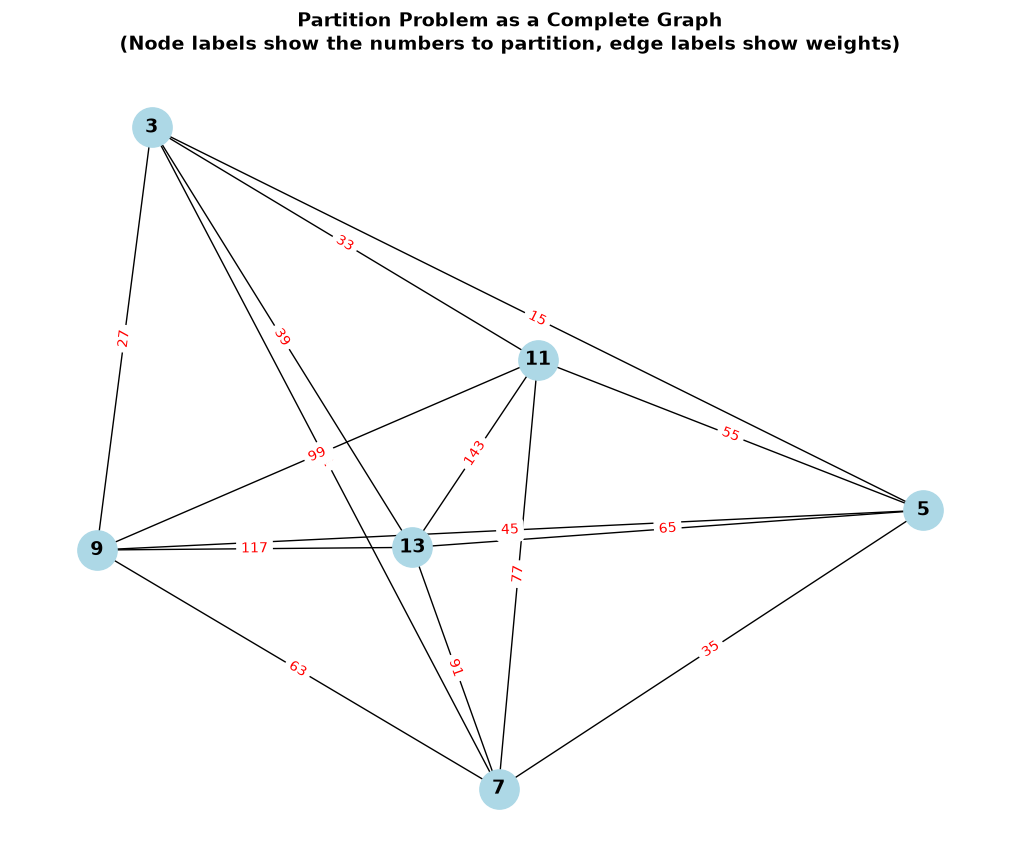


Each node represents a number from our set.
Edges connect all pairs, weighted by the product of the numbers.


In [9]:
plot_partition_graph(partition_graph, numbers, seed=seed, show=True)

In [10]:
## Verify your answer ##
grade_lab4b_ex1a(partition_graph)

Grading your answer. Please wait...



qiskit_runtime_service.__init__:WARNING:2026-07-31 16:18:41,288: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.


Congratulations! 🎉 Your partition graph is correct. The graph has 6 nodes and 15 edges, and each edge weight correctly represents the product of the two numbers it connects. 
You scored 1 on this exercise.


Now let's use QAOA to solve this partition problem by finding the MaxCut!

We'll convert the graph to a cost Hamiltonian, which in this case will be the partition Hamiltonian, and apply QAOA to find the optimal partition. To do that we encourage you to explore the [`qiskit_addon_opt_mapper`](https://qiskit.github.io/qiskit-addon-opt-mapper/) library and [`qopt_best_practices`](https://github.com/qiskit-community/qopt-best-practices) libraries to create the QAOA circuit and optimize its parameters.

<a id="exercise_1b"></a>
<div class="alert alert-block alert-success">
    
<b>Exercise 1b: From graph to Hamiltonian and quantum circuit </b> 

**Your Goal:** Convert the graph representation into the cost Hamiltonian and construct the QAOA circuit using the `qiskit_addon_opt_mapper`and `qopt_best_practices` libraries.

Note that the cost Hamiltonian is the partition Hamiltonian and needs to be a SparsePauliOp object.

In this exercise, you will transform the classical graph problem into a QAOA quantum circuit whose parameters we can optimize. This involves two key steps: creating the partition Hamiltonian that encodes the MaxCut objective, and building a parameterized quantum circuit.

**Hint:** Review the import statements at the top of the notebook to see which functions you might need.
Also take a look at the output of the [`to_ising`](https://github.com/Qiskit/qiskit-addon-opt-mapper/blob/main/qiskit_addon_opt_mapper/translators/ising.py#L24) function, and note that the function needs to take an `OptimizationProblem` input, not a [`Maxcut`](https://qiskit.github.io/qiskit-addon-opt-mapper/stubs/qiskit_addon_opt_mapper.applications.Maxcut.html#qiskit_addon_opt_mapper.applications.Maxcut) class.

</div>


#### Solution notes — Exercise 1b: Hamiltonian and ansatz

Two library calls do the work, and the split between them is the point of the
exercise.

**`Maxcut(partition_graph)` → `to_ising(...)`.** `Maxcut` wraps the graph as an
optimization problem object; `to_ising` returns a `(SparsePauliOp, offset)` pair.
The operator holds one $Z_i Z_j$ term per edge with coefficient $w_{ij}/2$; the
`offset` is the constant part that was dropped in the derivation above. The
offset is *not* passed to the ansatz — a constant shifts every eigenvalue
equally and so cannot change which bitstring is optimal — but you would need it
to convert a measured expectation value back into an actual cut size.

**`annotated_qaoa_ansatz(partition_hamiltonian, reps=layers)`.** Standard QAOA:
starting from $|+\rangle^{\otimes n}$, alternate $e^{-i\gamma_k H_C}$ and
$e^{-i\beta_k \sum_i X_i}$ for `reps` layers, giving `2 * reps` parameters. Here
`layers = 1`, so two parameters — enough for a 6-node instance, and cheap to
optimise.

The *annotated* part matters for hardware. Rather than emitting a flat gate
list, this version wraps each cost layer and each mixer layer in an annotated
box. `UnrollBoxes()` in the next cell opens those boxes only once the
swap-strategy pass has decided how to route the all-to-all interactions, so the
transpiler can reason about a whole commuting layer at a time instead of
peephole-optimising a sequence it no longer recognises as QAOA.

Note the circuit is copied *before* `measure_all()`: the Estimator path (used by
the training loop) needs the bare circuit, while the Sampler path needs the
measured one. Mixing them up is the usual first error here.

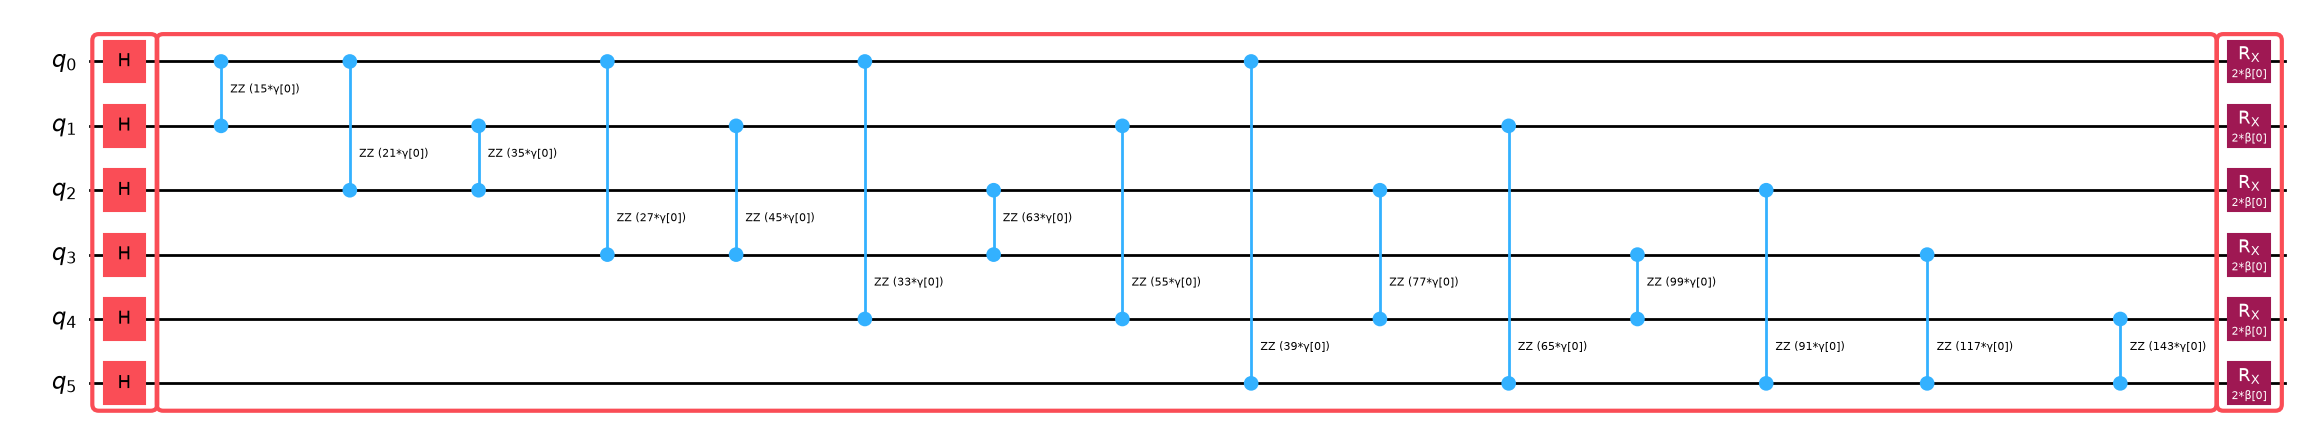

In [11]:
# reps=1: two variational parameters (one gamma, one beta). Plenty for six
# nodes, and it keeps the two-qubit depth low enough to survive the hardware.
layers = 1

# ---- TODO : Task 1b ---
# Maxcut wraps the weighted graph as an optimization problem; to_ising turns it
# into (SparsePauliOp, offset). The operator carries one Z_i Z_j term per edge.
maxcut = Maxcut(partition_graph)
# `offset` is the constant term dropped when expanding C^2. It is not fed to the
# ansatz -- a constant cannot change which bitstring is optimal -- but you need
# it to turn a measured expectation value back into a real cut size.
partition_hamiltonian, offset = to_ising(maxcut.to_optimization_problem())
# Note that we created an annotated_qaoa_ansatz circuit where the individual QAOA cost
# and QAOA mixer layers are annotated for improved transpilation
# The annotations keep each cost/mixer layer boxed until UnrollBoxes() opens
# them after routing, so the transpiler can optimise a whole commuting layer at
# once instead of a flattened gate list.
circuit = annotated_qaoa_ansatz(partition_hamiltonian, reps=layers)

# ---- end of TODO : Task 1b ---

# Now we draw the circuit and add the measurements for sampling
# Two variants are needed: the Estimator (training loop) takes the bare circuit,
# the Sampler (Section 2) needs the measured copy.
circuit_sampler = circuit.copy()
circuit_sampler.measure_all()
circuit.draw(idle_wires=False, fold=-1, output="mpl")

In [12]:
## Verify your answer ##
grade_lab4b_ex1b(partition_hamiltonian, circuit)

Grading your answer. Please wait...



qiskit_runtime_service.__init__:WARNING:2026-07-31 16:18:44,657: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.


Congratulations! 🎉 Your Hamiltonian and circuit are correct.
You scored 1 on this exercise.


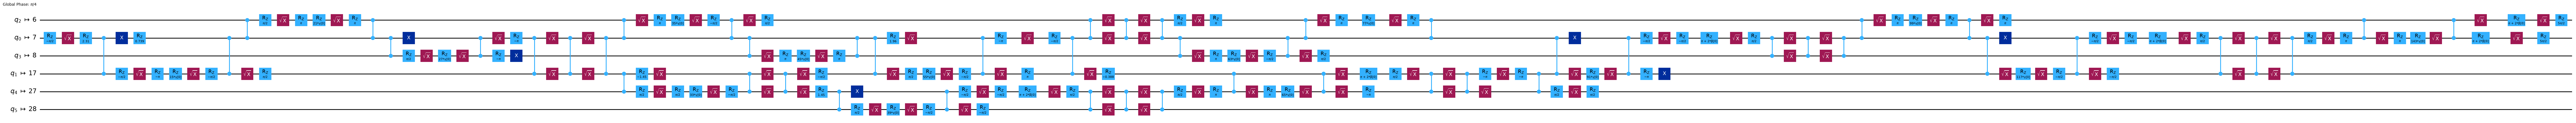

In [13]:
# Transpilation. Two pass managers are built here but only one is used: `pm`
# (the stock preset manager at optimization_level=3) does the actual work, while
# `staged_pm` -- the QAOA-aware manager -- is constructed and left commented out
# because this 6-node problem already fits the hardware graph. Section 3 does
# use `staged_pm`, where the 160-node instance genuinely needs routing.
#
# The edge colouring partitions the complete graph's edges into groups that act
# on disjoint qubit pairs, so all edges of one colour can be executed in
# parallel. `SwapStrategy(cmap, ())` is deliberately empty: an all-to-all
# coupling map with no SWAP layers, i.e. "assume connectivity, insert nothing".
#
# UnrollBoxes() opens the annotated cost/mixer boxes just before the pass
# manager runs, which is why it wraps the circuit rather than being a pass.

# Create pass manager for transpilation
pm = generate_preset_pass_manager(
    optimization_level=3, backend=backend, seed_transpiler=seed
)
edge_coloring = nx.greedy_color(
    nx.line_graph(partition_graph), strategy="saturation_largest_first"
)
edge_coloring.update({(k[1], k[0]): v for k, v in edge_coloring.items()})

num_colors = len(set(edge_coloring.values()))


# Make an empty swap strategy as we have a hardware-native graph here
cmap = CouplingMap(partition_graph.edges())
cmap.make_symmetric()

swap_strategy = SwapStrategy(cmap, ())  # no SWAPs needed

staged_pm = generate_preset_qaoa_pass_manager(
    backend, swap_strategy, initial_layout=None, edge_coloring=edge_coloring
)
# pm = staged_pm
candidate_circuit = pm.run(UnrollBoxes()(circuit))
candidate_circuit_sampler = pm.run(UnrollBoxes()(circuit_sampler))
candidate_circuit.draw("mpl", fold=False, idle_wires=False)

Now, we run the QAOA algorithm. You can either use the pre-trained parameters directly as an approximate solution by setting `training=False`, to skip the optimization step, or use them as an initial guess by passing them via `init_params` and setting `training=True`, allowing you to further optimize them and evaluate how much you can improve the results.

If you are not familiar with optimization loops in [Variational Quantum Algorithms](https://quantum.cloud.ibm.com/learning/courses/variational-algorithm-design/variational-algorithms) we recommend reviewing [this course](https://quantum.cloud.ibm.com/learning/courses/variational-algorithm-design/optimization-loops). For a more in-depth approach, you can also explore [this tutorial](https://quantum.cloud.ibm.com/docs/tutorials/quantum-approximate-optimization-algorithm) to see these concepts applied in a QAOA scenario.

In [14]:
ls qgss_2026_main

FAQ.md  lab-0/  lab-1/  lab-2/  lab-3/  lab-4/  LICENSE  utils/


In [15]:
# training=False reuses parameters optimised earlier on hardware, so the whole
# notebook can be read (and the mitigation comparison in Section 2 run) without
# paying for a 30-iteration COBYLA loop on a QPU. Set training=True in the next
# cell to optimise from these as a starting point instead.

training = False
init_params = np.load("qgss_2026_main/utils/pretrained_parameters_small.npy")

In [16]:
# The training loop, only entered when `training` is True above.
#
# cost_func_estimator is the objective COBYLA minimises. The one non-obvious
# line is `hamiltonian.apply_layout(ansatz.layout)`: the Hamiltonian was defined
# on virtual qubits 0..n-1, but transpilation permuted them onto physical
# qubits, so the observable has to be relabelled to match or every expectation
# value is silently measured on the wrong qubits.
#
# Session mode batches the ~30 iterations into one reservation so the queue is
# paid once instead of per iteration; the try/except falls back to Job mode for
# accounts (such as Open plan ones) that cannot open sessions.
#
# rhobeg=0.001 is a deliberately small initial COBYLA trust radius -- the
# pretrained parameters are already close, so large steps would only waste QPU
# time.

objective_func_vals = []  # Global variable


def cost_func_estimator(params, ansatz, hamiltonian, estimator):

    # transform the observable defined on virtual qubits to
    # an observable defined on all physical qubits
    isa_hamiltonian = hamiltonian.apply_layout(ansatz.layout)

    pub = (ansatz, isa_hamiltonian, params)
    job = estimator.run([pub])

    results = job.result()[0]
    cost = results.data.evs

    objective_func_vals.append(cost)

    return cost


max_iter = 30

if training:
    # Try with Session session, fallback to Job mode if it fails
    try:
        session = Session(backend=backend)
        estimator = Estimator(mode=session)
        use_session = True
        print("We are using Session mode")
    except:
        estimator = Estimator(mode=backend)
        use_session = False
        print("We are using Job mode")

    estimator.options.default_shots = 10000
    estimator.options.environment.job_tags = ["qgss26"]

    if use_session:
        with session:
            result = minimize(
                cost_func_estimator,
                init_params,
                args=(candidate_circuit, partition_hamiltonian, estimator),
                method="COBYLA",
                options={"maxiter": max_iter, "tol": 1e-8, "rhobeg": 0.001},
            )
    else:
        result = minimize(
            cost_func_estimator,
            init_params,
            args=(candidate_circuit, partition_hamiltonian, estimator),
            method="COBYLA",
            options={"maxiter": max_iter, "tol": 1e-8, "rhobeg": 0.001},
        )

    optimized_params = result.x
    np.save("optimized_parameters_small_custom.npy", optimized_params)
    plt.figure(figsize=(12, 6))
    plt.plot(objective_func_vals, lw=0.75, marker=".")
    plt.xlabel("Iteration")
    plt.ylabel("Cost")
    plt.show()


else:
    optimized_params = np.load("qgss_2026_main/utils/pretrained_parameters_small.npy")
optimized_circuit = candidate_circuit_sampler.assign_parameters(optimized_params)

# 2. Applying different Error Mitigation and Suppression techniques to the Sampler

Now we are going to apply different [error mitigation and suppression techniques](https://quantum.cloud.ibm.com/docs/guides/error-mitigation-and-suppression-techniques) to try to get the best results for the partition problem. This will complement the techniques you learned in Lab 3 from a more practical perspective - in particular, in a quantum optimization setting. 

<a id="exercise_2"></a>
<div class="alert alert-block alert-success">
    
<b>Exercise 2: Use the Sampler with different levels of Error Mitigation techniques</b>

**Your Goal:** Apply different error mitigation techniques to the quantum circuit execution and compare the results.

Test the following four configurations using 1000 shots:

- **2a: No Error Mitigation or Suppression** (baseline)  
  Raw hardware results without any error mitigation or suppression techniques

- **2b: Error Suppression + Twirling**  
  Dynamical Decoupling + Pauli Twirling (gates and measure) to suppress coherent errors during circuit execution

- **2c: M3 Error Mitigation Only**  
  Matrix-free Measurement Mitigation to correct readout errors in post-processing

- **2d: M3 Error Mitigation + Error Suppression + Twirling** (full stack)  
  Combined approach using both suppression during execution and mitigation in post-processing

Compare the accuracy and performance of each approach to understand the impact of different error mitigation strategies.

</div>

First we will define the [`SamplerOptions`](https://quantum.cloud.ibm.com/docs/api/qiskit-ibm-runtime/options-sampler-options) object for each case and then we will run the workflows.

#### Solution notes — Exercise 2: four Sampler configurations

The four versions are a 2×2 design: error **suppression** on/off, crossed with
readout **mitigation** on/off.

| | no M3 | with M3 |
|---|---|---|
| **no suppression** | v1 (baseline) | v3 |
| **DD + twirling** | v2 | v4 |

The distinction matters because the two families act at different times:

- **Suppression** changes the circuit *before* it runs. Dynamical decoupling
  fills idle windows with pulse sequences (`XY4` here) that echo away slow
  dephasing, so a qubit waiting on its neighbours does not just decohere. Pauli
  twirling randomises each two-qubit gate by conjugating it with random Paulis,
  which converts coherent, systematic errors — the kind that add up
  amplitude-wise across a circuit — into stochastic Pauli noise that merely
  averages out. Neither costs extra shots.
- **Mitigation (M3)** is post-processing on the counts. Nothing about the
  execution changes; the measured distribution is corrected afterwards.

Because v3 and v4 are pure post-processing, the notebook **reuses** the jobs from
v1 and v2 (`counts_bin_v3 = counts_bin_v1`). Only two hardware jobs are ever
submitted for four results. That is the practical lesson: readout mitigation is
free in QPU time, suppression is free in shots, and only the combination costs
you anything beyond the baseline.

**Why `num_randomizations = "auto"`?** Twirling only helps if you average over
several random Paulis; `"auto"` lets the runtime pick a count from the shot
budget rather than making you tune it. With 1000 shots it will split them across
a handful of randomizations.

In [17]:
# =============================================================================
# VERSION 1: No Error Mitigation or Suppression
# =============================================================================
# Baseline. Everything below is measured against this.
print("=" * 80)
print("VERSION 1: No Error Mitigation or Suppression")
print("=" * 80)

options_v1 = SamplerOptions()
# ---- TODO : Task 2a ---
# Set the number of shots to 1000 and define the SamplerOptions for the quantum circuit execution
# A fresh SamplerOptions() already has every mitigation and suppression flag
# off, so setting the shot count is the whole of Task 2a.
shots = 1000
options_v1.default_shots = shots
# ---- end of TODO : Task 2a ---

VERSION 1: No Error Mitigation or Suppression


In [18]:
## Verify your answer ##
grade_lab4b_ex2a(options_v1)

Grading your answer. Please wait...



qiskit_runtime_service.__init__:WARNING:2026-07-31 16:18:50,374: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.


Congratulations! 🎉  Your error mitigation analysis on the Sampler looks correct.
You scored 1 on this exercise.


Now apply [Dynamical Decoupling](https://quantum.cloud.ibm.com/docs/api/qiskit-ibm-runtime/options-dynamical-decoupling-options) and [Pauli Twirling](https://quantum.cloud.ibm.com/docs/api/qiskit-ibm-runtime/options-twirling-options) (gates and measure twirling). 

In [19]:
# =============================================================================
# VERSION 2: Error Suppression Only (Dynamical Decoupling + Twirling)
# =============================================================================
# Both techniques act before/during execution and cost no extra shots.
print("=" * 80)
print("VERSION 2: Error Suppression Only")
print("=" * 80)


options_v2 = SamplerOptions()
# ---- TODO : Task 2b ---
# Configure error suppression options
options_v2.default_shots = 1000
# Set dynamical decoupling to reduce decoherence errors
# XY4 = X-Y-X-Y pulses inserted into idle windows. It refocuses both dephasing
# axes, so it is more robust than the simpler X-X sequence at roughly the same
# pulse cost.
options_v2.dynamical_decoupling.enable = True
options_v2.dynamical_decoupling.sequence_type = "XY4"
# Enable gate twirling to randomize coherent errors
# Conjugating each 2q gate with random Paulis turns coherent (amplitude-adding)
# error into stochastic Pauli noise, which averages out instead of accumulating.
options_v2.twirling.enable_gates = True
# Enable measurement twirling to randomize readout errors
# Same trick at readout: random bit flips before measurement, undone in
# classical post-processing, which symmetrises asymmetric 0->1 vs 1->0 error.
options_v2.twirling.enable_measure = True
# "auto" lets the runtime split the shot budget across randomizations for you.
options_v2.twirling.num_randomizations = "auto"

# ---- end of TODO : Task 2b ---

VERSION 2: Error Suppression Only


In [20]:
## Verify your answer ##
grade_lab4b_ex2b(options_v2)

Grading your answer. Please wait...



qiskit_runtime_service.__init__:WARNING:2026-07-31 16:18:52,961: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.


Congratulations! 🎉  Your error mitigation analysis on the Sampler looks correct.
You scored 1 on this exercise.


Now that you have succesfully completed Ex2a and Ex2b, we will run those workflows to use the results to be further post-processed by the M3 technique.

*Usage estimate: 5 seconds on a Heron r2 processor (NOTE: This is an estimate only. Your runtime might vary.)*

*The usage estimate reflects only backend execution. Cell runtime can still take minutes due to queueing, calibration, and session delays. You can check the status of your job in [IBM Quantum Platform](https://quantum.cloud.ibm.com/).*

In [ ]:
# =============================================================================
# VERSION 1: No Error Mitigation or Suppression
# =============================================================================
# No error mitigation or suppression options set
sampler_v1 = Sampler(mode=backend, options=options_v1)
sampler_v1.options.environment.job_tags = ["qgss26"]

pub_v1 = (optimized_circuit,)
job_v1 = sampler_v1.run([pub_v1], shots=shots)
print ("Job ID of job_v1:", job_v1.job_id())
counts_bin_v1 = job_v1.result()[0].data.meas.get_counts()

final_distribution_bin_v1 = {key: val / shots for key, val in counts_bin_v1.items()}

final_distribution_bin_v1 = dict(
    sorted(final_distribution_bin_v1.items(), key=lambda item: item[1], reverse=True)
)
print("Results (no mitigation):")
print(final_distribution_bin_v1)

Job ID of job_v1: d9mbpnmh4e6s738v0j5g


**Troubleshooting: Retrieving Lost Jobs**

If you lose access to your job variables due to a kernel restart or session interruption, you can still retrieve your results without rerunning the job on hardware. This saves valuable QPU time. Execute the cell below to retrieve a job using its job ID.

If you do not have the job ID readily available, you can find it in [IBM Quantum Platform](https://quantum.cloud.ibm.com/) by checking your job history under the Jobs tab.

In [ ]:
job_id_v1= job_v1.job_id()
# Alternatively, you can also subsittute the job_id_v1 by the actual string of the job ID, e.g. "d8slqn5bh0os73eoe0lk"
job_v1_retrieved = service.job(job_id_v1)

*Usage estimate: 5 seconds on a Heron r2 processor (NOTE: This is an estimate only. Your runtime might vary.)*

*The usage estimate reflects only backend execution. Cell runtime can still take minutes due to queueing, calibration, and session delays. You can check the status of your job in [IBM Quantum Platform](https://quantum.cloud.ibm.com/).*

In [ ]:
# =============================================================================
# VERSION 2: Error Suppression Only (Dynamical Decoupling + Twirling)
# =============================================================================
sampler_v2 = Sampler(mode=backend, options=options_v2)
sampler_v2.options.environment.job_tags = ["qgss26"]

pub_v2 = (optimized_circuit,)
job_v2 = sampler_v2.run([pub_v2], shots=shots)
print ("Job ID of job_v2:", job_v2.job_id())
counts_bin_v2 = job_v2.result()[0].data.meas.get_counts()
final_distribution_bin_v2 = {key: val / shots for key, val in counts_bin_v2.items()}
final_distribution_bin_v2 = dict(
    sorted(final_distribution_bin_v2.items(), key=lambda item: item[1], reverse=True)
)
print("Results (error suppression only):")
print(final_distribution_bin_v2)
print()

Job ID of job_v2: d9m3s308csec73f9kc4g
Results (error suppression only):
{'101001': 0.038, '010111': 0.033, '110000': 0.03, '101100': 0.03, '100110': 0.028, '011000': 0.027, '110010': 0.026, '001111': 0.026, '011011': 0.026, '101000': 0.025, '010110': 0.023, '010101': 0.023, '101101': 0.022, '110001': 0.022, '011101': 0.021, '001101': 0.021, '011001': 0.021, '100100': 0.021, '100011': 0.02, '101010': 0.02, '010100': 0.02, '100010': 0.02, '111000': 0.02, '001110': 0.02, '110100': 0.02, '100111': 0.02, '010011': 0.019, '000111': 0.019, '011010': 0.019, '001100': 0.019, '101011': 0.018, '011100': 0.018, '100101': 0.018, '010010': 0.018, '001011': 0.018, '011110': 0.014, '101110': 0.014, '000110': 0.014, '001010': 0.013, '000101': 0.012, '110101': 0.012, '100001': 0.012, '100000': 0.011, '111011': 0.008, '000010': 0.007, '110111': 0.007, '001001': 0.007, '000100': 0.007, '110110': 0.006, '101111': 0.006, '111001': 0.006, '001000': 0.006, '110011': 0.006, '011111': 0.006, '111110': 0.005, '

After running these two workflows, we can use the obtained counts to be analyzed by M3.

The M3 ([Matrix‑free Measurement Mitigation](https://qiskit.github.io/qiskit-addon-mthree/)) method is a scalable approach to readout error mitigation that avoids constructing the full $2^n \times 2^n$ assignment matrix by using simplified models of readout errors. It assumes that correlations of order three and higher are negligible, which allows it to rely only on single-qubit and two-qubit assignment matrices obtained by preparing all qubits in the $\lvert 0\ldots0\rangle$ and $\lvert 1\ldots1\rangle$ states and measuring their error rates. These small $2\times2$ and $4\times4$ matrices are stored and later combined to form an effective mitigation matrix that is built only from the bitstrings observed during sampling. Because the size of this effective matrix grows with the number of sampled outcomes rather than $2^n$, M3 can be applied to circuits with much longer bitstrings than traditional linear algebra methods.

Now you are asked to use it to reduce the error in the sampling of the quantum circuit. See this [tutorial](https://quantum.cloud.ibm.com/docs/tutorials/readout-error-mitigation-sampler) for a more in-depth analysis. Also, if you want a more hands-on approach to see which functions you need to apply, see [this tutorial](https://qiskit.github.io/qiskit-addon-mthree/tutorials/01_M3_ex1.html).

*Usage estimate: 7 seconds on a Heron r2 processor (NOTE: This is an estimate only. Your runtime might vary.)*

*The usage estimate reflects only backend execution. Cell runtime can still take minutes due to queueing, calibration, and session delays. You can check the status of your job in [IBM Quantum Platform](https://quantum.cloud.ibm.com/).*

#### Solution notes — Exercises 2c and 2d: M3

M3 needs three things, in order, and the exercise is really about getting that
order right:

1. **`final_measurement_mapping(optimized_circuit)`** — which *physical* qubit
   each classical bit came from. After transpilation the virtual-to-physical map
   is a permutation, so calibrating the wrong qubits is the easy mistake here.
   Note it is read from `optimized_circuit`, the transpiled circuit, not the
   logical one.
2. **`cals_from_system(meas_map)`** — submits a short calibration job that
   prepares and measures $|0\ldots0\rangle$ and $|1\ldots1\rangle$ on exactly
   those qubits, giving the per-qubit $2\times2$ assignment matrices.
3. **`apply_correction(counts, meas_map)`** — solves for the corrected
   distribution.

The output is **quasi-probabilities**, not probabilities: entries can be
negative, because inverting a noisy stochastic map need not land inside the
probability simplex. That is what `convert_bin_list` handles — it clips
negatives to zero and renormalises. Clipping is a pragmatic choice rather than a
principled one (the statistically proper fix is a constrained least-squares
projection onto the simplex), but for picking out the single most likely
bitstring it is fine.

**Why M3 is "matrix-free":** the exact correction needs a $2^n \times 2^n$
assignment matrix — hopeless past ~20 qubits. M3 assumes readout errors are
uncorrelated beyond pairs, so it stores only small per-qubit matrices and builds
the mitigation operator restricted to the handful of bitstrings that actually
appeared in the counts. Cost scales with the number of *observed* bitstrings,
not with $2^n$.

Version 4 is identical to version 3 except that it corrects the *suppressed*
counts from v2 instead of the raw counts from v1 — suppression and mitigation
compose, since they act at different stages.

In [ ]:
# M3 runs entirely on the counts from version 1: `options_v3 = options_v1` and
# `job_v3 = job_v1` are reuse, not re-execution. Readout mitigation costs no
# extra QPU time beyond the short calibration job that cals_from_system submits.

# =============================================================================
# VERSION 3: M3 Error Mitigation Only
# =============================================================================
print("=" * 80)
print("VERSION 3: M3 Error Mitigation Only")
print("=" * 80)

# We copy the setup from version 1, but focus only on M3 mitigation
options_v3 = options_v1
counts_bin_v3 = counts_bin_v1
job_v3 = job_v1
# ---- TODO : Task 2c ---
# Get the physical qubit mapping from the optimized circuit using the mthree.utils.final_measurement_mapping function

meas_map_v3 = mthree.utils.final_measurement_mapping(optimized_circuit)

# Build mitigator using mthree.M3Mitigation
mit_v3 = mthree.M3Mitigation(backend)

# Calibrate the mitigator using the .cals_from_system method and the meas_map_v3
mit_v3.cals_from_system(meas_map_v3)

# Use the .apply_correction method on counts_bin_v3 to returns quasi-probabilities
m3_quasis_v3 = mit_v3.apply_correction(counts_bin_v3, meas_map_v3)
# ---- end of TODO : Task 2c ---

def convert_bin_list(dist, shots=10000):
    # Step 1: convert to (non-negative) counts
    counts = {
        k: (int(round(float(v) * shots)) if float(v) >= 0 else 0)
        for k, v in dist.items()
    }
    # Step 2: normalize
    total_counts = sum(counts.values())
    return {k: round(v / total_counts, int(np.log10(shots))) for k, v in counts.items()}


final_distribution_bin_v3 = convert_bin_list(dict(m3_quasis_v3), shots=shots)
final_distribution_bin_v3 = dict(
    sorted(final_distribution_bin_v3.items(), key=lambda item: item[1], reverse=True)
)
print("Results (M3 mitigation only):")
print(final_distribution_bin_v3)
print()

VERSION 3: M3 Error Mitigation Only
Results (M3 mitigation only):
{'011010': 0.038, '101000': 0.035, '110010': 0.035, '011000': 0.033, '101010': 0.033, '011011': 0.031, '010110': 0.03, '100100': 0.03, '010101': 0.029, '110000': 0.027, '100110': 0.026, '101001': 0.026, '110001': 0.025, '011100': 0.023, '001110': 0.022, '010011': 0.022, '010100': 0.021, '011001': 0.021, '100001': 0.021, '100010': 0.02, '110011': 0.02, '110100': 0.02, '010010': 0.019, '010111': 0.019, '001100': 0.018, '001111': 0.018, '011110': 0.018, '001010': 0.016, '100011': 0.016, '011101': 0.015, '101100': 0.015, '111000': 0.015, '001101': 0.014, '100000': 0.014, '100101': 0.014, '000110': 0.012, '100111': 0.012, '000000': 0.01, '000111': 0.01, '001001': 0.01, '010001': 0.01, '001011': 0.009, '010000': 0.009, '101101': 0.009, '101110': 0.009, '111001': 0.009, '110110': 0.008, '111010': 0.008, '000010': 0.007, '011111': 0.007, '101011': 0.007, '110101': 0.007, '111110': 0.007, '110111': 0.006, '111111': 0.006, '000001

In [ ]:
## Verify your answer ##
grade_lab4b_ex2c(options_v3, optimized_circuit, meas_map_v3, m3_quasis_v3, counts_bin_v3)

Grading your answer. Please wait...



qiskit_runtime_service.__init__:WARNING:2026-07-31 07:49:46,022: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.


Congratulations! 🎉  Your error mitigation analysis on the Sampler looks correct.
You scored 1 on this exercise.


*Usage estimate: 7 seconds on a Heron r2 processor (NOTE: This is an estimate only. Your runtime might vary.)*

*The usage estimate reflects only backend execution. Cell runtime can still take minutes due to queueing, calibration, and session delays. You can check the status of your job in [IBM Quantum Platform](https://quantum.cloud.ibm.com/).*

In [ ]:
# Identical to version 3, except it corrects the *suppressed* counts from
# version 2. Suppression and mitigation act at different stages (before vs after
# execution), so they compose.

# =============================================================================
# VERSION 4: M3 Error Mitigation + Error Suppression
# =============================================================================
print("=" * 80)
print("VERSION 4: M3 Error Mitigation + Error Suppression")
print("=" * 80)

options_v4 = options_v2
counts_bin_v4 = counts_bin_v2
job_v4 = job_v2
# ---- TODO : Task 2d ---
# Apply M3 correction on top of error suppression
# Get the physical qubit mapping from the optimized circuit using the mthree.utils.final_measurement_mapping function

meas_map_v4 = mthree.utils.final_measurement_mapping(optimized_circuit)

# Build mitigator using mthree.M3Mitigation
mit_v4 = mthree.M3Mitigation(backend)

# Calibrate the mitigator using the .cals_from_system method and the meas_map_v4
mit_v4.cals_from_system(meas_map_v4)

# Use the .apply_correction method on counts_bin_v4 to returns quasi-probabilities
m3_quasis_v4 = mit_v4.apply_correction(counts_bin_v4, meas_map_v4)

# ---- End of TODO : Task 2d ---
final_distribution_bin_v4 = convert_bin_list(dict(m3_quasis_v4), shots=shots)
final_distribution_bin_v4 = dict(
    sorted(final_distribution_bin_v4.items(), key=lambda item: item[1], reverse=True)
)
print("Results (M3 mitigation + error suppression):")
print(final_distribution_bin_v4)
print()

VERSION 4: M3 Error Mitigation + Error Suppression
Results (M3 mitigation + error suppression):
{'101001': 0.04, '010111': 0.035, '101100': 0.031, '110000': 0.03, '100110': 0.029, '001111': 0.027, '011000': 0.027, '011011': 0.027, '110010': 0.027, '101000': 0.025, '010101': 0.023, '010110': 0.023, '101101': 0.023, '110001': 0.023, '011101': 0.022, '001101': 0.021, '001110': 0.021, '011001': 0.021, '100011': 0.021, '100111': 0.021, '101010': 0.021, '011010': 0.02, '100010': 0.02, '100100': 0.02, '110100': 0.02, '111000': 0.02, '000111': 0.019, '010011': 0.019, '010100': 0.019, '101011': 0.019, '001011': 0.018, '001100': 0.018, '011100': 0.018, '100101': 0.018, '010010': 0.017, '011110': 0.015, '101110': 0.014, '000110': 0.013, '001010': 0.013, '110101': 0.012, '000101': 0.011, '100001': 0.011, '100000': 0.01, '111011': 0.008, '110111': 0.007, '000010': 0.006, '000100': 0.006, '001001': 0.006, '011111': 0.006, '101111': 0.006, '110011': 0.006, '110110': 0.006, '111001': 0.006, '001000': 

In [ ]:
## Verify your answer ##
grade_lab4b_ex2d(options_v4, optimized_circuit, meas_map_v4, m3_quasis_v4, counts_bin_v4)

Grading your answer. Please wait...



qiskit_runtime_service.__init__:WARNING:2026-07-31 07:51:38,769: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.


Congratulations! 🎉  Your error mitigation analysis on the Sampler looks correct.
You scored 1 on this exercise.


In [ ]:
# =============================================================================
# Summary Comparison
# =============================================================================
print("=" * 80)
print("SUMMARY")
print("=" * 80)
print("V1 (No mitigation):              ", list(final_distribution_bin_v1.items())[:3])
print("V2 (Suppression only):           ", list(final_distribution_bin_v2.items())[:3])
print("V3 (M3 only):                    ", list(final_distribution_bin_v3.items())[:3])
print("V4 (M3 + Suppression):           ", list(final_distribution_bin_v4.items())[:3])

SUMMARY
V1 (No mitigation):               [('011010', 0.037), ('110010', 0.034), ('101000', 0.034)]
V2 (Suppression only):            [('101001', 0.038), ('010111', 0.033), ('110000', 0.03)]
V3 (M3 only):                     [('011010', 0.038), ('101000', 0.035), ('110010', 0.035)]
V4 (M3 + Suppression):            [('101001', 0.04), ('010111', 0.035), ('101100', 0.031)]


In [ ]:
bitstring_v1, set1_v1, set2_v1, difference_v1, v1 = analyze_partition_result(
    final_distribution_bin_v1, numbers, partition_graph, "VERSION 1: No Mitigation"
)
bitstring_v2, set_v2, set2_v2, difference_v2, v2 = analyze_partition_result(
    final_distribution_bin_v2,
    numbers,
    partition_graph,
    "VERSION 2: Error Suppression Only",
)
bitstring_v3, set1_v3, set2_v3, difference_v3, v3 = analyze_partition_result(
    final_distribution_bin_v3, numbers, partition_graph, "VERSION 3: M3 Mitigation Only"
)
bitstring_v4, set1_v4, set2_v4, difference_v4, v4 = analyze_partition_result(
    final_distribution_bin_v4,
    numbers,
    partition_graph,
    "VERSION 4: M3 + Error Suppression",
)


Analysis for VERSION 1: No Mitigation
Result bitstring: [0, 1, 0, 1, 1, 0]

QAOA Partition Result:
Set 1: [5, 9, 11] (sum = 25)
Set 2: [3, 7, 13] (sum = 23)
Difference: 2

Analysis for VERSION 2: Error Suppression Only
Result bitstring: [1, 0, 0, 1, 0, 1]

QAOA Partition Result:
Set 1: [3, 9, 13] (sum = 25)
Set 2: [5, 7, 11] (sum = 23)
Difference: 2

Analysis for VERSION 3: M3 Mitigation Only
Result bitstring: [0, 1, 0, 1, 1, 0]

QAOA Partition Result:
Set 1: [5, 9, 11] (sum = 25)
Set 2: [3, 7, 13] (sum = 23)
Difference: 2

Analysis for VERSION 4: M3 + Error Suppression
Result bitstring: [1, 0, 0, 1, 0, 1]

QAOA Partition Result:
Set 1: [3, 9, 13] (sum = 25)
Set 2: [5, 7, 11] (sum = 23)
Difference: 2


In [ ]:
# Collect results in a structured way
results_sampler = {
    "v1": {
        "bitstring": bitstring_v1,
        "set1": set1_v1,
        "set2": set2_v1,
        "difference": difference_v1,
        "label": "VERSION 1: No Mitigation",
    },
    "v2": {
        "bitstring": bitstring_v2,
        "set1": set_v2,
        "set2": set2_v2,
        "difference": difference_v2,
        "label": "VERSION 2: Error Suppression Only",
    },
    "v3": {
        "bitstring": bitstring_v3,
        "set1": set1_v3,
        "set2": set2_v3,
        "difference": difference_v3,
        "label": "VERSION 3: M3 Mitigation Only",
    },
    "v4": {
        "bitstring": bitstring_v4,
        "set1": set1_v4,
        "set2": set2_v4,
        "difference": difference_v4,
        "label": "VERSION 4: M3 + Error Suppression",
    },
}

# Select the version with the smallest difference
best_key, best_result = min(
    reversed(list(results_sampler.items())), key=lambda item: item[1]["difference"]
)

# Print summary
print("\n✅ Best result:")
print(f"Method     : {best_key} ({best_result['label']})")
print(f"Bitstring  : {best_result['bitstring']}")
print(f"Set 1      : {best_result['set1']}")
print(f"Set 2      : {best_result['set2']}")
print(f"Difference : {best_result['difference']}")


✅ Best result:
Method     : v4 (VERSION 4: M3 + Error Suppression)
Bitstring  : [1, 0, 0, 1, 0, 1]
Set 1      : [3, 9, 13]
Set 2      : [5, 7, 11]
Difference : 2


Now we are going to check that you have correctly executed all the jobs using the `SamplerOptions` you defined above.

In [ ]:
options_list = [options_v1, options_v2, options_v3, options_v4]
probs_list = [
    final_distribution_bin_v1,
    final_distribution_bin_v2,
    final_distribution_bin_v3,
    final_distribution_bin_v4,
]
job_list = [job_v1, job_v2, job_v3, job_v4]

In [ ]:
## Verify your answer ##
grade_lab4b_ex2(options_list, probs_list, job_list)

Grading your answer. Please wait...



qiskit_runtime_service.__init__:WARNING:2026-07-31 07:51:58,359: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.


Congratulations! 🎉  Your error mitigation analysis on the Sampler looks correct.
You scored 1 on this exercise.


## 3. Scaling to Larger Problems: Pauli Correlation Encoding

Now let's tackle a more complicated graph of 160 nodes. To handle such large problems on current quantum hardware with limited qubits, we need to reduce the number of qubits required. 

**Pauli Correlation Encoding** is a technique for encoding multiple classical variables using fewer qubits by exploiting correlations in the problem structure. Instead of using one qubit per node, we encode node states in the correlations between pairs of qubits. The figure below provides a visual illustration of how this encoding works.

<div style="text-align:center;">
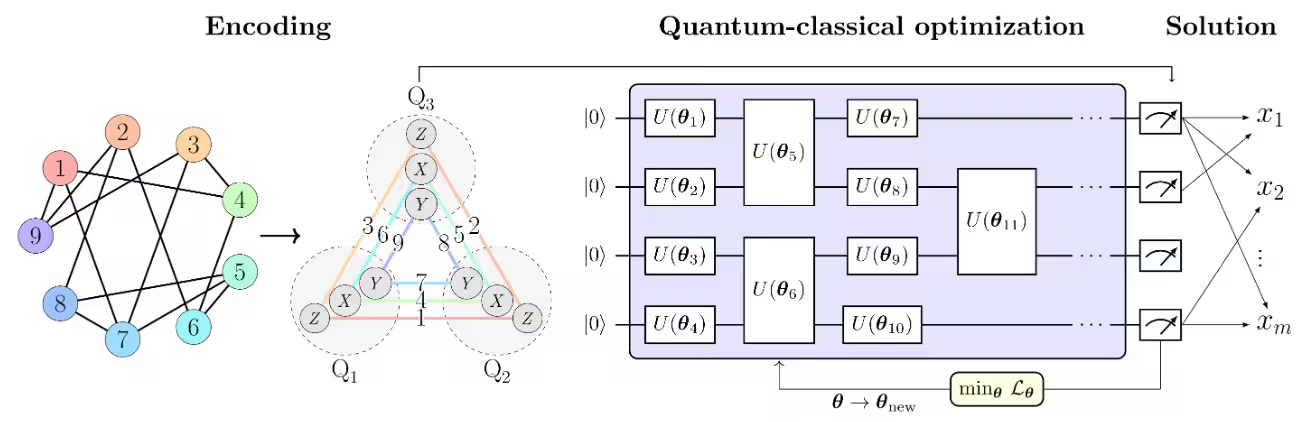
</div>

For more details, refer to [the Pauli Correlation Encoding tutorial](https://quantum.cloud.ibm.com/docs/tutorials/pauli-correlation-encoding-for-qaoa) based on [Sciorili et al.](https://www.nature.com/articles/s41467-024-55346-z).

In [ ]:
ls

qgss_2026_main/  README.md


In [ ]:
n = 160
# We pre-generated 160 random integers in [0, 100] using np.random.randint(0, 100, size=n)
# For reproducibility, we load this pre-generated numbers here
numbers_large = np.load("qgss_2026_main/utils/numbers_large.npy")

print(f"Numbers to partition: {numbers_large}")
print(f"Total sum: {sum(numbers_large)}")

partition_graph_large = build_partition_graph(numbers_large)

print(
    f"\nGraph created with {len(partition_graph_large.nodes())} nodes and {len(partition_graph_large.edges())} edges"
)

Numbers to partition: [51 92 14 71 60 20 82 86 74 74 87 99 23  2 21 52  1 87 29 37  1 63 59 20
 32 75 57 21 88 48 90 58 41 91 59 79 14 61 61 46 61 50 54 63  2 50  6 20
 72 38 17  3 88 59 13  8 89 52  1 83 91 59 70 43  7 46 34 77 80 35 49  3
  1  5 53  3 53 92 62 17 89 43 33 73 61 99 13 94 47 14 71 77 86 61 39 84
 79 81 52 23 25 88 59 40 28 14 44 64 88 70  8 87  0  7 87 62 10 80  7 34
 34 32  4 40 27  6 72 71 11 33 32 47 22 61 87 36 98 43 85 90 34 64 98 46
 77  2  0  4 89 13 26  8 78 14 89 41 76 50 62 95]
Total sum: 7853

Graph created with 160 nodes and 12720 edges


Following what is done in [this tutorial](https://quantum.cloud.ibm.com/docs/tutorials/pauli-correlation-encoding-for-qaoa) and in [this paper](https://www.nature.com/articles/s41467-024-55346-z), we can reduce the number of qubits by order $\mathcal{O}(\sqrt{n})$.

<a id="exercise_3a"></a>
<div class="alert alert-block alert-success">
    
<b>Exercise 3a: Implement Pauli Correlation Encoding: Qubit reduction </b> 

**Your Goal:** Reduce the number of qubits from $n$ to $\mathcal{O}(\sqrt{n})$ by using Pauli Correlation Encoding. Check out the paper or the tutorial for the specific formula. 

Also, define the lists `node_x`, `node_y`, and `node_z` to specify which nodes are encoded using Pauli X, Y, and Z operators.



</div>

#### Solution notes — Exercise 3a: how PCE saves qubits

Standard encoding is one qubit per node: 160 nodes, 160 qubits. PCE instead
reads each node off a **two-body Pauli correlation** — the expectation value
$\langle P_i P_j \rangle$ of a Pauli on a *pair* of qubits — so the number of
available slots grows quadratically with the qubit count instead of linearly.

With $m$ qubits there are $\binom{m}{2} = m(m-1)/2$ pairs, and three Pauli
choices ($X$, $Y$, $Z$) give three independent families of them. So $m$ qubits
encode up to

$$3 \cdot \frac{m(m-1)}{2} \ \ge\ n$$

nodes. Solving $3m(m-1)/2 = n$ for $m$ with the quadratic formula gives exactly
the expression in the code:

$$m = \left\lceil \frac{1 + \sqrt{1 + \tfrac{8}{3} n}}{2} \right\rceil$$

For $n = 160$: $\sqrt{1 + 426.67} \approx 20.68$, so $m = \lceil 10.84 \rceil = 11$.
**160 nodes on 11 qubits** — and 3·11·10/2 = 165 ≥ 160 slots, so it fits with
five to spare. The bonus section's 1600 nodes need only 33 qubits.

`node_x`, `node_y`, `node_z` then split the $n$ nodes into three equal blocks,
one per Pauli family. The split is arbitrary — any assignment works as long as
no pair-and-Pauli combination is reused — and equal thirds simply keep each
family within its $\binom{m}{2}$ budget.

**What you give up.** The qubit saving is not free: the mapping is no longer
linear, so the cost function has to be built from the correlations by hand (the
`tanh` loss in the next cells) rather than read straight off a Hamiltonian, and
each node's value now comes from an estimated expectation value rather than a
measured bit. The `tanh(alpha * <P_i P_j>)` in the loss is exactly the
sharpening step that pushes these continuous values back toward ±1.

In [ ]:
# Pauli Correlation Encoding: instead of one qubit per node, each node is read
# off the expectation value of a two-body Pauli correlation <P_i P_j>. With m
# qubits there are m(m-1)/2 pairs times 3 Pauli families, so capacity grows
# quadratically -- 160 nodes fit on 11 qubits. See the notes above for the
# derivation of the formula.

# ---- TODO : Task 3a ---
def reduce_qubits_with_pce(initial_qubits: int) -> int:
    """
    Reduce the number of qubits from n to O(sqrt(n)) using Pauli Correlation Encoding.
    
    Parameters
    ----------
    initial_qubits : int
        The original number of qubits before encoding.
    
    Returns
    -------
    int
        The reduced number of qubits after applying PCE.
    Examples
        --------
        >>> reduce_qubits_with_pce(160)
        11
    """
    final_qubits = int(np.ceil((1 + np.sqrt(1 + (8 / 3) * initial_qubits)) / 2))
    return final_qubits



list_size = n // 3
node_x = [i for i in range(list_size)]
node_y = [i for i in range(list_size, 2 * list_size)]
node_z = [i for i in range(2 * list_size, n)]

# ---- TODO : Task 3a ---
num_qubits = reduce_qubits_with_pce(n)
print(f"Number of qubits: {num_qubits}")
print("List 1:", node_x)
print("List 2:", node_y)
print("List 3:", node_z)

Number of qubits: 11
List 1: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52]
List 2: [53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105]
List 3: [106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159]


In [ ]:
## Verify your answer ##
grade_lab4b_ex3a(reduce_qubits_with_pce, node_x, node_y, node_z)

Grading your answer. Please wait...



qiskit_runtime_service.__init__:WARNING:2026-07-31 07:52:10,033: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.


Congratulations! 🎉  Your Pauli Correlation Encoding implementation is correct.
You scored 1 on this exercise.


<a id="exercise_3b"></a>
<div class="alert alert-block alert-success">
    
<b>Exercise 3b: Implement Pauli Correlation Encoding: Hamiltonian construction </b> 

**Your Goal:** Implement <code>build_pauli_correlation_encoding</code> to generate 2-body Pauli correlation Hamiltonian terms.
Use the lists <code>node_x</code>, <code>node_y</code>, and <code>node_z</code> to control how logical nodes are encoded using Pauli X, Y, and Z operators.




</div>

#### Solution notes — Exercise 3b: building the correlation operators

Each node needs its own two-qubit Pauli string. `combinations(range(n), k)` with
`k=2` enumerates the qubit pairs in a fixed order, and node $i$ of `node_list`
is assigned the $i$-th pair — hence the `if idx >= len(node_list): break`, which
stops once every node in this family has a pair. Any unused pairs (five of the
165, here) are simply left out.

Two details are easy to get wrong:

- **`n` is the qubit count, not the node count.** The parameter is named `n` but
  the calls pass `num_qubits` (11). The Pauli strings must be 11 characters
  long. Passing 160 here produces strings that no 11-qubit circuit can measure.
- **`[::-1]` for endianness.** Qiskit labels Pauli strings right-to-left: in
  `"IIX"` the `X` is on qubit 0. The loop fills `paulis[q] = pauli` using
  left-to-right indexing, so the string is reversed before being handed to
  `SparsePauliOp`. Skip this and the encoding still "works" — it just silently
  measures a different, mirrored set of qubit pairs, and the optimisation
  converges to a partition of the wrong graph.

The function returns a **list of single-term operators**, one per node, rather
than one summed operator. That is deliberate: the loss function needs each
node's expectation value separately, so they cannot be combined here. They are
only summed into `hamiltonian_pce` in Exercise 3c, and that sum exists purely so
`annotated_qaoa_ansatz` has something to build a circuit from.

In [ ]:
# One Pauli string per node. Watch two things: `n` is the *qubit* count (11),
# not the node count (160); and the [::-1] reversal is required because Qiskit
# reads Pauli labels right-to-left. See the notes above.

def build_pauli_correlation_encoding(pauli: str, node_list: list, n: int, k=2) -> list:
    """
    Build a list of Pauli Hamiltonian terms encoding k-body correlations
    for a given Pauli operator.

    This function constructs Pauli strings acting with the given `pauli`
    operator on all k-combinations of qubits (up to the size of `node_list`)
    and returns them as SparsePauliOp Hamiltonian terms with unit weight.

    Parameters
    ----------
    pauli : str
        Single-qubit Pauli operator ("X", "Y", or "Z").
    node_list : list
        List of nodes (or indices) used to limit the number of correlations.
    n : int
        Total number of qubits.
    k : int, optional
        Order of correlation (default is 2 for pairwise correlations).

    Returns
    -------
    hamiltonian : list of SparsePauliOp
        List of Hamiltonian terms encoding the Pauli correlations.
    """
    # ---- TODO : Task 3b ---
    pauli_strings = []
    for idx, c in enumerate(combinations(range(n), k)):
        if idx >= len(node_list):
            break
        paulis = ["I"] * n
        for q in c:
            paulis[q] = pauli
        # Reverse to match Qiskit's little-endian (right-to-left) qubit ordering
        pauli_strings.append(("".join(paulis)[::-1], 1))

    hamiltonian = []
    for pauli_string, weight in pauli_strings:
        hamiltonian.append(SparsePauliOp.from_list([(pauli_string, weight)]))
    # ---- END of TODO : Task 3b ---
    return hamiltonian


pauli_correlation_encoding_x = build_pauli_correlation_encoding("X", node_x, num_qubits)
pauli_correlation_encoding_y = build_pauli_correlation_encoding("Y", node_y, num_qubits)
pauli_correlation_encoding_z = build_pauli_correlation_encoding("Z", node_z, num_qubits)

In [ ]:
## Verify your answer ##
grade_lab4b_ex3b(
    pauli_correlation_encoding_x,
    pauli_correlation_encoding_y,
    pauli_correlation_encoding_z,
)

Grading your answer. Please wait...



qiskit_runtime_service.__init__:WARNING:2026-07-31 07:52:23,199: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.


Congratulations! 🎉 Your Pauli correlation encodings are correct.
You scored 1 on this exercise.


<a id="exercise_3c"></a>
<div class="alert alert-block alert-success">
    
<b>Exercise 3c: Implement Pauli Correlation Encoding: Cost Hamiltonian and QAOA ansatz </b> 

**Your Goal:** Combine the Pauli Correlation Encoding Hamiltonian terms into a single cost Hamiltonian (a SparsePauliOp object) and use it to construct the corresponding QAOA ansatz.


</div>

#### Solution notes — Exercise 3c: from correlations to an ansatz

`hamiltonian_pce` concatenates the three families into one `SparsePauliOp`.
`.simplify()` merges duplicate Pauli strings and drops zero coefficients — with
disjoint pair assignments there should be nothing to merge, so it mainly acts as
a canonicalisation step.

The important thing to understand is that **this operator is not the cost
function**. Every term has coefficient 1; it carries no information about the
graph weights at all. Its only job is to hand `annotated_qaoa_ansatz` a set of
two-qubit interactions to build layers from — it determines the *circuit
structure*, nothing more. The real objective lives in `loss_func_estimator`,
which measures the three families separately and assembles the weighted cut
through `tanh`.

This is the structural difference from Section 1. There, the QAOA ansatz was
generated from the actual cost Hamiltonian and the Estimator returned the
objective directly. Here the ansatz is only a parameterised state, and the
objective is computed classically from 160 individual expectation values. It is
QAOA-shaped rather than QAOA proper.

`reps=2` (up from 1) because the state now has to express a much richer
correlation pattern on only 11 qubits.

In [ ]:
# Two layers now, not one: 11 qubits have to carry 160 nodes' worth of
# correlation structure, so the state needs more expressivity.
layers_large = 2
# ---- TODO : Task 3c ---
ops = (
    pauli_correlation_encoding_x
    + pauli_correlation_encoding_y
    + pauli_correlation_encoding_z
)
# Flatten the list of single-term operators into one SparsePauliOp. simplify()
# merges duplicate Pauli labels and drops zero coefficients; with disjoint pair
# assignments there is nothing to merge, so it is really a canonicalisation.
labels = []
coeffs = []
for op in ops:
    labels.extend(op.paulis.to_labels())
    coeffs.extend(op.coeffs.tolist())
hamiltonian_pce = SparsePauliOp(labels, coeffs).simplify()

# This operator is NOT the cost function -- every coefficient is 1 and it knows
# nothing about the graph weights. It exists only to tell annotated_qaoa_ansatz
# which two-qubit interactions to build layers from. The real objective is
# assembled in loss_func_estimator from the three families' expectation values.
circuit_pce = annotated_qaoa_ansatz(hamiltonian_pce, reps=layers_large)

# ---- END of TODO : Task 3c ---

In [ ]:
## Verify your answer ##
grade_lab4b_ex3c(hamiltonian_pce, circuit_pce)

Grading your answer. Please wait...



qiskit_runtime_service.__init__:WARNING:2026-07-31 07:52:31,821: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.


Congratulations! 🎉 Your Pauli Correlation Encoding Hamiltonian and QAOA circuit are correct.
You scored 1 on this exercise.


Let's transpile the circuit:

In [ ]:
# Unlike Section 1, this transpilation actually uses the QAOA-aware pass manager
# (`pm = staged_pm`). The PCE ansatz has interactions between every pair of the
# 11 qubits, which no hardware coupling map provides, so the swap strategy and
# edge colouring now do real work: routing the all-to-all pattern into parallel
# layers of hardware-native gates.

edge_coloring = nx.greedy_color(
    nx.line_graph(partition_graph), strategy="saturation_largest_first"
)
edge_coloring.update({(k[1], k[0]): v for k, v in edge_coloring.items()})

num_colors = len(set(edge_coloring.values()))


cmap = CouplingMap(partition_graph.edges())
cmap.make_symmetric()
swap_strategy = SwapStrategy(cmap, ())
staged_pm = generate_preset_qaoa_pass_manager(
    backend, swap_strategy, initial_layout=None, edge_coloring=edge_coloring
)


pm = staged_pm

circuit_pce = pm.run(UnrollBoxes()(circuit_pce))

We define the loss function following the paper.

In [ ]:
# The PCE loss, following Sciorilli et al. (Nat. Commun. 2025). Three points:
#
# 1. One Estimator job covers all three Pauli families (three PUBs), and the
#    `job` argument lets you replay a completed job instead of resubmitting --
#    that is what the "retrieving lost jobs" cells use.
# 2. tanh(alpha * <P_i P_j>) sharpens each continuous expectation value toward
#    +-1, recovering a binary partition assignment from a soft one. alpha is set
#    to num_qubits, so the sharpening gets more aggressive as the problem grows.
# 3. The regularisation term penalises states where the tanh values are all
#    saturated in the same direction, i.e. the degenerate "everything in one
#    partition" solution that trivially maximises nothing.

def loss_func_estimator(x, ansatz, hamiltonian, estimator, graph, experiment_result=[], job = None):
    """
    Calculates the specified loss function for the given ansatz, Hamiltonian, and graph.

    The expectation values of each Pauli string in the Hamiltonian are first obtained
    by running the ansatz on the quantum backend. These expectation values are then
    passed through the nonlinear function tanh(alpha * prod_i). The loss function is
    subsequently computed from these transformed values.
    """
    if job is None:
        job = estimator.run(
            [
                (ansatz, hamiltonian[0], x),
                (ansatz, hamiltonian[1], x),
                (ansatz, hamiltonian[2], x),
            ]
        )
        print("Creating new Job:", job.job_id())
    else:
        print("Using existing Job:", job.job_id())
    try:
        result = job.result()
    except:
        print(
            "Error: Unable to retrieve results from the job. "
            "Please verify that you are passing the correct job variable to the function."
        )
        return None, None, None

    # calculate the loss function
    node_exp_map = {}
    idx = 0
    for r in result:
        for ev in r.data.evs:
            node_exp_map[idx] = ev
            idx += 1

    loss = 0
    alpha = num_qubits
    for edge0, edge1, weight in graph.edges(data="weight"):
        loss += (
            weight
            * np.tanh(alpha * node_exp_map[edge0])
            * np.tanh(alpha * node_exp_map[edge1])
        )
    regulation_term = 0
    for i in range(len(graph.nodes())):
        regulation_term += np.tanh(alpha * node_exp_map[i]) ** 2
    regulation_term = regulation_term / len(graph.nodes())
    regulation_term = regulation_term**2
    beta = 1 / 2
    v = len(graph.edges()) / 2 + (len(graph.nodes()) - 1) / 4
    regulation_term = beta * v * regulation_term

    loss = loss + regulation_term

    print(f"Iter {len(experiment_result)}: {loss}")
    experiment_result.append(
        {"loss": loss, "exp_map": node_exp_map, "job_result": result}
    )
    return loss, experiment_result, job

In [ ]:
# apply_layout is applied per-operator and kept as three separate lists, not one
# flat list: loss_func_estimator submits one PUB per family and needs each
# node's expectation value individually. Collapsing them into a single summed
# observable would return one number and destroy the encoding.

# Build PCE operators with layout applied
# Note that here we need a list of 3 Hamiltonians, one for each Pauli term, instead of a single Hamiltonian such
pce = [
    [op.apply_layout(circuit_pce.layout) for op in pauli_correlation_encoding_x],
    [op.apply_layout(circuit_pce.layout) for op in pauli_correlation_encoding_y],
    [op.apply_layout(circuit_pce.layout) for op in pauli_correlation_encoding_z],
]


def run_pce_optimization(
    qc,
    backend,
    pce,
    partition_graph,
    loss_func_estimator,
    seed=seed,
    max_iter=30,
    training=False,
    filename="qgss_2026_main/utils/pretrained_parameters_pce",
):

    counter = {"i": 0}
    last_x = {"value": None}
    last_fun = {"value": None}

    np.random.seed(seed)
    initial_params = 2 * np.pi * np.random.rand(qc.num_parameters)

    experiment_result = []

    if training:
        # Try with session, fallback to job if it fails
        try:
            session = Session(backend=backend)
            estimator = Estimator(mode=session)
            use_session = True
            print("We are using Session mode")
        except:
            estimator = Estimator(mode=backend)
            use_session = False
            print("We are using Job mode")

        estimator.options.default_shots = 10000
        estimator.options.environment.job_tags = ["qgss26"]

        def loss_func(x, experiment_result):
            last_x["value"] = x.copy()
            if counter["i"] + 1 > max_iter:
                return last_fun["value"]

            counter["i"] += 1

            val, experiment_result, _ = loss_func_estimator(
                x, qc, pce, estimator, partition_graph, experiment_result
            )

            last_fun["value"] = val
            return val

        if use_session:
            with session:
                result = minimize(
                    loss_func,
                    initial_params,
                    experiment_result,
                    method="COBYLA",
                    options={"maxiter": max_iter},
                )
        else:
            result = minimize(
                loss_func,
                initial_params,
                experiment_result,
                method="COBYLA",
                options={"maxiter": max_iter},
            )

        optimized_params = result.x
        np.save(filename, optimized_params)

    else:
        optimized_params = np.load(filename)

    return optimized_params, experiment_result


# You can use the pretrained parameters or run the optimization by setting `training=True`
optimized_params_pce, experiment_result_pce = run_pce_optimization(
    circuit_pce,
    backend,
    pce,
    partition_graph_large,
    loss_func_estimator,
    training=False,
    filename="qgss_2026_main/utils/pretrained_parameters_pce.npy",
)


## 4. Error Mitigation Comparison for PCE-Expanded Partition Problem

Building on the PCE-scaled partition problem from Section 3, we now use the Estimator primitive to systematically compare different [error mitigation techniques](https://quantum.cloud.ibm.com/learning/courses/utility-scale-quantum-computing/error-mitigation) and identify the best possible cut, progressing from basic readout error mitigation to advanced probabilistic error cancellation and zero noise extrapolation. Check out [this tutorial](https://quantum.cloud.ibm.com/docs/tutorials/combine-error-mitigation-techniques) to see how these techniques work in practice.


<a id="exercise_4"></a>
<div class="alert alert-block alert-success">
    
<b>Exercise 4: Use the Estimator with different levels of Error Mitigation techniques</b>

**Your Goal:** Apply different error mitigation techniques to the quantum circuit execution using the Estimator primitive and compare the results.

Test the following four configurations with increasing sophistication:

- **4a: No Error Mitigation** (baseline)  
  Raw hardware results without any mitigation

- **4b: TREX (Twirled Readout Error eXtinction) + PT (Pauli Twirling on gates and measures)**  
  Mitigates measurement readout errors through randomized twirling

- **4c: ZNE (Zero Noise Extrapolation) + PT (Pauli Twirling on gates and measures)**  
  Extrapolates results to the zero-noise limit using multiple noise-scaled circuits

- **4d: PEC (Probabilistic Error Cancellation) + PT (Pauli Twirling on gates and measures)**  
  Uses quasi-probability decomposition to cancel gate errors probabilistically

Compare the accuracy, computational overhead, and performance of each approach to understand the trade-offs between different error mitigation strategies.

*Note that for each configuration, you must explicitly enable the desired techniques in `EstimatorOptions`. Just setting the resilience level will not be accepted by the grader.*
</div>

First we build the `EstimatorOptions` without any error mitigation or suppression technique, just defining the number of shots to 1000.

#### Solution notes — Exercise 4: four Estimator configurations

Same comparison as Exercise 2, but with the Estimator and with genuinely
expensive techniques. The four scenarios are ordered by cost:

| | What it does | Overhead | Bias vs variance |
|---|---|---|---|
| **No EM** | nothing | 1× | biased, cheap |
| **TREX** | twirls readout, inverts the symmetrised error | ~1× | removes readout bias |
| **ZNE** | runs at amplified noise, extrapolates to zero | ~3× | unbiased-ish, higher variance |
| **PEC** | quasi-probability inversion of the noise channel | up to ~50× | unbiased, variance blows up |

The QPU-time estimates printed in the notebook tell the story better than any
explanation: 12 s for no-EM, 12 s for TREX, 16 s for ZNE, and **4 min 26 s** for
PEC — more than twenty times the baseline for the same three PUBs.

- **TREX** twirls the measurement so readout error becomes a symmetric bit-flip
  channel, which can then be inverted analytically. Essentially free, and it is
  why `resilience.measure_mitigation = True` is the first thing to reach for.
- **ZNE** deliberately makes things worse — running the circuit at 1×, 2×, 3×
  noise (by gate folding or pulse stretching) — then fits a curve and
  extrapolates back to zero noise. The cost is the extra noise factors; the risk
  is that the extrapolation model is wrong, which shows up as bias you cannot
  see.
- **PEC** is the principled one: learn the noise channel, express the ideal
  operation as a signed combination of noisy ones, and sample from it. It is
  unbiased, but the sampling overhead grows *exponentially* in circuit error
  rate. That exponential is the 4½ minutes.

**Note the exercise's own warning:** setting `resilience_level` alone is not
accepted. The level is a preset that may or may not enable a given technique
depending on the runtime version, so each flag is set explicitly. That is good
practice outside the lab too.

Also note Exercise 4d explicitly sets `zne_mitigation = False` before enabling
PEC. The two are mutually exclusive, and if a previous cell left ZNE on in the
shared options object the runtime would reject the job.

In [ ]:
# No Error Mitigation (Resilience Level 0)
# Baseline for the four-way comparison. 12 s of QPU time.
print("=" * 80)
print("Scenario 1: No Error Mitigation (Resilience Level 0)")
print("=" * 80)

est_options_no_em = EstimatorOptions()
# ---- TODO : Task 4a ---
# Configure estimator options without error mitigation and using your preferred number of shots
# A fresh EstimatorOptions() has every resilience and twirling flag off, so the
# shot count is all that is needed. 10000 shots here rather than the Sampler's
# 1000, because expectation values need tighter statistics than mode-finding.
est_options_no_em.default_shots = 10000
# ---- END of TODO : Task 4a ---

Scenario 1: No Error Mitigation (Resilience Level 0)


In [ ]:
## Verify your answer ##
grade_lab4b_ex4a(est_options_no_em)

Grading your answer. Please wait...



qiskit_runtime_service.__init__:WARNING:2026-07-31 07:52:55,696: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.


Congratulations! 🎉 Your baseline configuration (no error mitigation) is correct.
You scored 1 on this exercise.


Now we build the EstimatorOptions using [Twirled Readout Error eXtinction (TREX)](https://quantum.cloud.ibm.com/docs/guides/error-mitigation-and-suppression-techniques#twirled-readout-error-extinction-trex), which reduces measurement errors by randomly flipping qubits before readout, and [Pauli Twirling](https://quantum.cloud.ibm.com/docs/guides/error-mitigation-and-suppression-techniques#pauli-twirling), which converts arbitrary noise channels into noise channels with more specific structure.

In [ ]:
#  TREX (Twirled Readout Error eXtinction)
# Roughly free: same 12 s as the baseline.
print("=" * 80)
print("Running with TREX (Twirled Readout Error eXtinction)")
print("=" * 80)
estimator_trex = Estimator(backend)
est_options_trex = EstimatorOptions()
# ---- TODO : Task 4b ---
# Configure estimator options with TREX (measurement error mitigation)
est_options_trex.default_shots = 10000
# Enable TREX - uses twirling to mitigate readout errors
# Twirling the measurement turns readout error into a symmetric bit-flip
# channel, which can then be inverted analytically. Set the flag explicitly
# rather than relying on resilience_level -- the grader requires it, and the
# level presets are not stable across runtime versions.
est_options_trex.resilience.measure_mitigation = True
# Enable gate twirling (both gates and measure)
est_options_trex.twirling.enable_gates = True
est_options_trex.twirling.enable_measure = True

# ---- END of TODO : Task 4b ---

Running with TREX (Twirled Readout Error eXtinction)


In [ ]:
## Verify your answer ##
grade_lab4b_ex4b(est_options_trex)

Grading your answer. Please wait...



qiskit_runtime_service.__init__:WARNING:2026-07-31 07:53:04,008: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.


Congratulations! 🎉 Your TREX configuration is correct.
You scored 1 on this exercise.


Now we implement [Zero Noise Extrapolation (ZNE)](https://quantum.cloud.ibm.com/docs/guides/error-mitigation-and-suppression-techniques#zero-noise-extrapolation-zne), which intentionally amplifies circuit noise at different levels and extrapolates the results back to estimate the zero-noise limit, and [Pauli Twirling](https://quantum.cloud.ibm.com/docs/guides/error-mitigation-and-suppression-techniques#pauli-twirling).

In [ ]:
# Scenario 3: ZNE (Zero Noise Extrapolation) + Gate Twirling
# ~16 s: the extra noise factors cost roughly a third more than the baseline.
print("=" * 80)
print("Scenario 3: ZNE (Zero Noise Extrapolation) + Gate Twirling")
print("=" * 80)
estimator_zne = Estimator(backend)
est_options_zne = EstimatorOptions()
# ---- TODO : Task 4c ---
# Configure estimator options with ZNE and gate twirling
est_options_zne.default_shots = 10000

# Apply ZNE to extrapolate results to the zero-noise limit by running circuits at different noise levels
# Deliberately amplify the noise (gate folding / pulse stretching), measure at
# each level, fit, and extrapolate back to zero. Unbiased only if the
# extrapolation model is right -- a wrong model produces invisible bias.
est_options_zne.resilience.zne_mitigation = True

# Enable gate twirling (both gates and measure)
# ZNE assumes the amplified noise is stochastic; twirling is what makes that
# assumption approximately true, so the two are normally used together.
est_options_zne.twirling.enable_gates = True
est_options_zne.twirling.enable_measure = True
# ---- END of TODO : Task 4c ---

Scenario 3: ZNE (Zero Noise Extrapolation) + Gate Twirling


In [ ]:
## Verify your answer ##
grade_lab4b_ex4c(est_options_zne)

Grading your answer. Please wait...



qiskit_runtime_service.__init__:WARNING:2026-07-31 07:53:13,283: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.


Congratulations! 🎉 Your ZNE configuration is correct.
You scored 1 on this exercise.


Finally, we implement [Probabilistic Error Cancellation (PEC)](https://quantum.cloud.ibm.com/docs/guides/error-mitigation-and-suppression-techniques#probabilistic-error-cancellation-pec), which mitigates errors by probabilistically inverting noisy operations using quasi-probability distributions, and [Pauli Twirling](https://quantum.cloud.ibm.com/docs/guides/error-mitigation-and-suppression-techniques#pauli-twirling).

In [ ]:
# Scenario 4: PEC (Probabilistic Error Cancellation) + Gate Twirling
# The expensive one: 4 min 26 s, over 20x the baseline, for the same three PUBs.
print("=" * 80)
print("Scenario 4: PEC (Probabilistic Error Cancellation) + Gate Twirling")
print("=" * 80)

est_options_pec = EstimatorOptions()
# ---- TODO : Task 4d ---
# Configure estimator options with PEC and gate twirling
est_options_pec.default_shots = 10000
# Disable ZNE since we want to use PEC instead (set to False)
# ZNE and PEC are mutually exclusive; setting this explicitly guards against a
# shared/reused options object arriving with ZNE still enabled.
est_options_pec.resilience.zne_mitigation = False
# Activate pec_mitigation to use PEC
# Learn the noise channel, write the ideal gate as a signed combination of noisy
# ones, sample from it. Unbiased in principle, but the sampling overhead grows
# exponentially with circuit error rate -- hence the 4.5 minutes.
est_options_pec.resilience.pec_mitigation = True


# Enable gate twirling (both gates and measure)
# PEC needs the noise to be Pauli-structured for the quasi-probability
# decomposition to be tractable; twirling is what enforces that structure.
est_options_pec.twirling.enable_gates = True
est_options_pec.twirling.enable_measure = True

# ---- END of TODO : Task 4d ---

Scenario 4: PEC (Probabilistic Error Cancellation) + Gate Twirling


In [ ]:
## Verify your answer ##
grade_lab4b_ex4d(est_options_pec)

Grading your answer. Please wait...



qiskit_runtime_service.__init__:WARNING:2026-07-31 07:53:21,430: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.


Congratulations! 🎉 Your PEC configuration is correct.
You scored 1 on this exercise.


With all `EstimatorOptions` properly configured, we can now execute the workflows on real quantum hardware. Before running the following cells, carefully review the estimated QPU time consumption to manage your quantum computing resources effectively.


*Usage estimate: 12 seconds on a Heron r2 processor (NOTE: This is an estimate only. Your runtime might vary.)*

*The usage estimate reflects only backend execution. Cell runtime can still take minutes due to queueing, calibration, and session delays. You can check the status of your job in [IBM Quantum Platform](https://quantum.cloud.ibm.com/).*

In [ ]:
estimator_no_em = Estimator(backend, options=est_options_no_em)
estimator_no_em.options.environment.job_tags = ["qgss26"]

# Calculate loss with optimized parameters
experiment_no_em = []
loss_no_em, experiment_no_em, job_no_em = loss_func_estimator(
    optimized_params_pce,
    circuit_pce,
    [pce[0], pce[1], pce[2]],
    estimator_no_em,
    partition_graph_large,
    experiment_no_em,
)

Creating new Job: d9m4cpvbupns73e88bvg
Error: Unable to retrieve results from the job. Please verify that you are passing the correct job variable to the function.


**Troubleshooting: Retrieving Lost Jobs**

If you lose access to your job variables due to a kernel restart or session interruption, you can still retrieve your results without rerunning the job on hardware, saving valuable QPU time.

To recover your results, first retrieve the job using its job_id as shown previously. Then, execute a workflow by passing the retrieved job to the `loss_func_estimator` function, as demonstrated in the cell below.

In [ ]:
# The hardcoded string is a job ID, not a credential: it identifies a completed
# run in the IBM Quantum job history and is only useful to the account that
# submitted it. Retrieving a finished job costs no QPU time, which is the point
# of this cell -- a kernel restart does not mean paying for the run again.
job_no_em_retrieved = service.job("d9m4cpvbupns73e88bvg") # or substitute the argument for the string (e.g. "")
experiment_no_em = []
# Passing the retrieved job as the last argument makes loss_func_estimator skip
# submission and recompute the loss from the stored results.
loss_no_em, experiment_no_em, job_no_em = loss_func_estimator(
    optimized_params_pce,
    circuit_pce,
    [pce[0], pce[1], pce[2]],
    estimator_no_em,
    partition_graph_large,
    experiment_no_em,
    job_no_em_retrieved,
)

*Usage estimate: 12 seconds on a Heron r2 processor (NOTE: This is an estimate only. Your runtime might vary.)*

*The usage estimate reflects only backend execution. Cell runtime can still take minutes due to queueing, calibration, and session delays. You can check the status of your job in [IBM Quantum Platform](https://quantum.cloud.ibm.com/).*

In [ ]:
estimator_trex = Estimator(backend, options=est_options_trex)
estimator_trex.options.environment.job_tags = ["qgss26"]

# Calculate loss with TREX
experiment_trex = []
loss_trex, experiment_trex, job_trex = loss_func_estimator(
    optimized_params_pce,
    circuit_pce,
    [pce[0], pce[1], pce[2]],
    estimator_trex,
    partition_graph_large,
    experiment_trex,
)

*Usage estimate: 16 seconds on a Heron r2 processor (NOTE: This is an estimate only. Your runtime might vary.)*

*The usage estimate reflects only backend execution. Cell runtime can still take minutes due to queueing, calibration, and session delays. You can check the status of your job in [IBM Quantum Platform](https://quantum.cloud.ibm.com/).*

In [ ]:
estimator_zne = Estimator(backend, options=est_options_zne)
estimator_zne.options.environment.job_tags = ["qgss26"]
# Calculate loss with ZNE
experiment_zne = []
loss_zne, experiment_zne, job_zne = loss_func_estimator(
    optimized_params_pce,
    circuit_pce,
    [pce[0], pce[1], pce[2]],
    estimator_zne,
    partition_graph_large,
    experiment_zne,
)

<div class="alert alert-block alert-warning">

*Usage estimate: 4 min and 26 seconds on a Heron r2 processor (NOTE: This is an estimate only. Your runtime might vary.)*

*The usage estimate reflects only backend execution. Cell runtime can still take minutes due to queueing, calibration, and session delays. You can check the status of your job in [IBM Quantum Platform](https://quantum.cloud.ibm.com/).*
</div>

If you are not comfortable using that amount of QPU time, you can run the job on a simulator instead. However, this will give less accurate results and will not show how PEC mitigates real hardware noise. To run it on simulator, change the backend and add a coupling map by uncommenting the next cell.

If you want to use the QPU and better understand PEC in practice, skip the commented cell and run the job as-is.

In [ ]:
# backend = AerSimulator.from_backend(backend)
# est_options_pec.simulator = {
#    "coupling_map": CouplingMap.from_full(backend.configuration().n_qubits)
#}

In [ ]:
estimator_pec = Estimator(backend, options=est_options_pec)
estimator_pec.options.environment.job_tags = ["qgss26"]

# Calculate loss with PEC
experiment_pec = []
loss_pec, experiment_pec, job_pec = loss_func_estimator(
    optimized_params_pce,
    circuit_pce,
    [pce[0], pce[1], pce[2]],
    estimator_pec,
    partition_graph_large,
    experiment_pec,
)

Let's analyze the results now!

In [ ]:
# Step 1: Analyze baseline (No Error Mitigation)
results = {}
results["No EM"] = analyze_error_mitigation_result(
    loss=loss_no_em,
    experiment_result=experiment_no_em,
    partition_graph=partition_graph_large,
    numbers=numbers_large,  # List of actual numbers being partitioned
)

# Step 2: Analyze TREX with baseline comparison
results["TREX"] = analyze_error_mitigation_result(
    loss=loss_trex,
    experiment_result=experiment_trex,
    partition_graph=partition_graph_large,
    numbers=numbers_large,
)

# Step 3: Analyze ZNE + GT with baseline comparison
results["ZNE"] = analyze_error_mitigation_result(
    loss=loss_zne,
    experiment_result=experiment_zne,
    partition_graph=partition_graph_large,
    numbers=numbers_large,
)

# Step 4: Analyze PEC + GT with baseline comparison
results["PEC"] = analyze_error_mitigation_result(
    loss=loss_pec,
    experiment_result=experiment_pec,
    partition_graph=partition_graph_large,
    numbers=numbers_large,
)

# Step 5: Create comparison dataframe
comparison_df = compare_error_mitigation_methods(results, baseline_key="No EM")

# Step 6: Print summary with key findings
print_comparison_summary(comparison_df)

# Step 7: Plot comprehensive visualizations
plot_error_mitigation_comparison(comparison_df)

# Access individual results:
print("\n" + "=" * 80)
print("DETAILED RESULTS:")
print("=" * 80)

for method_name, result in results.items():
    print(f"\n{method_name}:")
    print(f"  Loss: {result['loss']:.2f}")
    print(f"  Best Cut: {result['best_cut']:.2f}")
    print(f"  Partitions: {result['par0_size']} vs {result['par1_size']} nodes")
    print(f"  Difference in the sums of the partitions: {result['difference']}")
    print(
        f"  Set 0: {result['set0'][:10]}..."
        if len(result["set0"]) > 10
        else f"  Set 0: {result['set0']}"
    )
    print(
        f"  Set 1: {result['set1'][:10]}..."
        if len(result["set1"]) > 10
        else f"  Set 1: {result['set1']}"
    )

    if "loss_improvement_pct" in result:
        print(f"  Improvement: {result['loss_improvement_pct']:.2f}%")
        print(f"  Cut Difference: {result['cut_diff']:.2f}")

##### Your results should look similar to those below. These were obtained from a previous job run on `ibm_pittsburgh`.

<div style="text-align:center;">
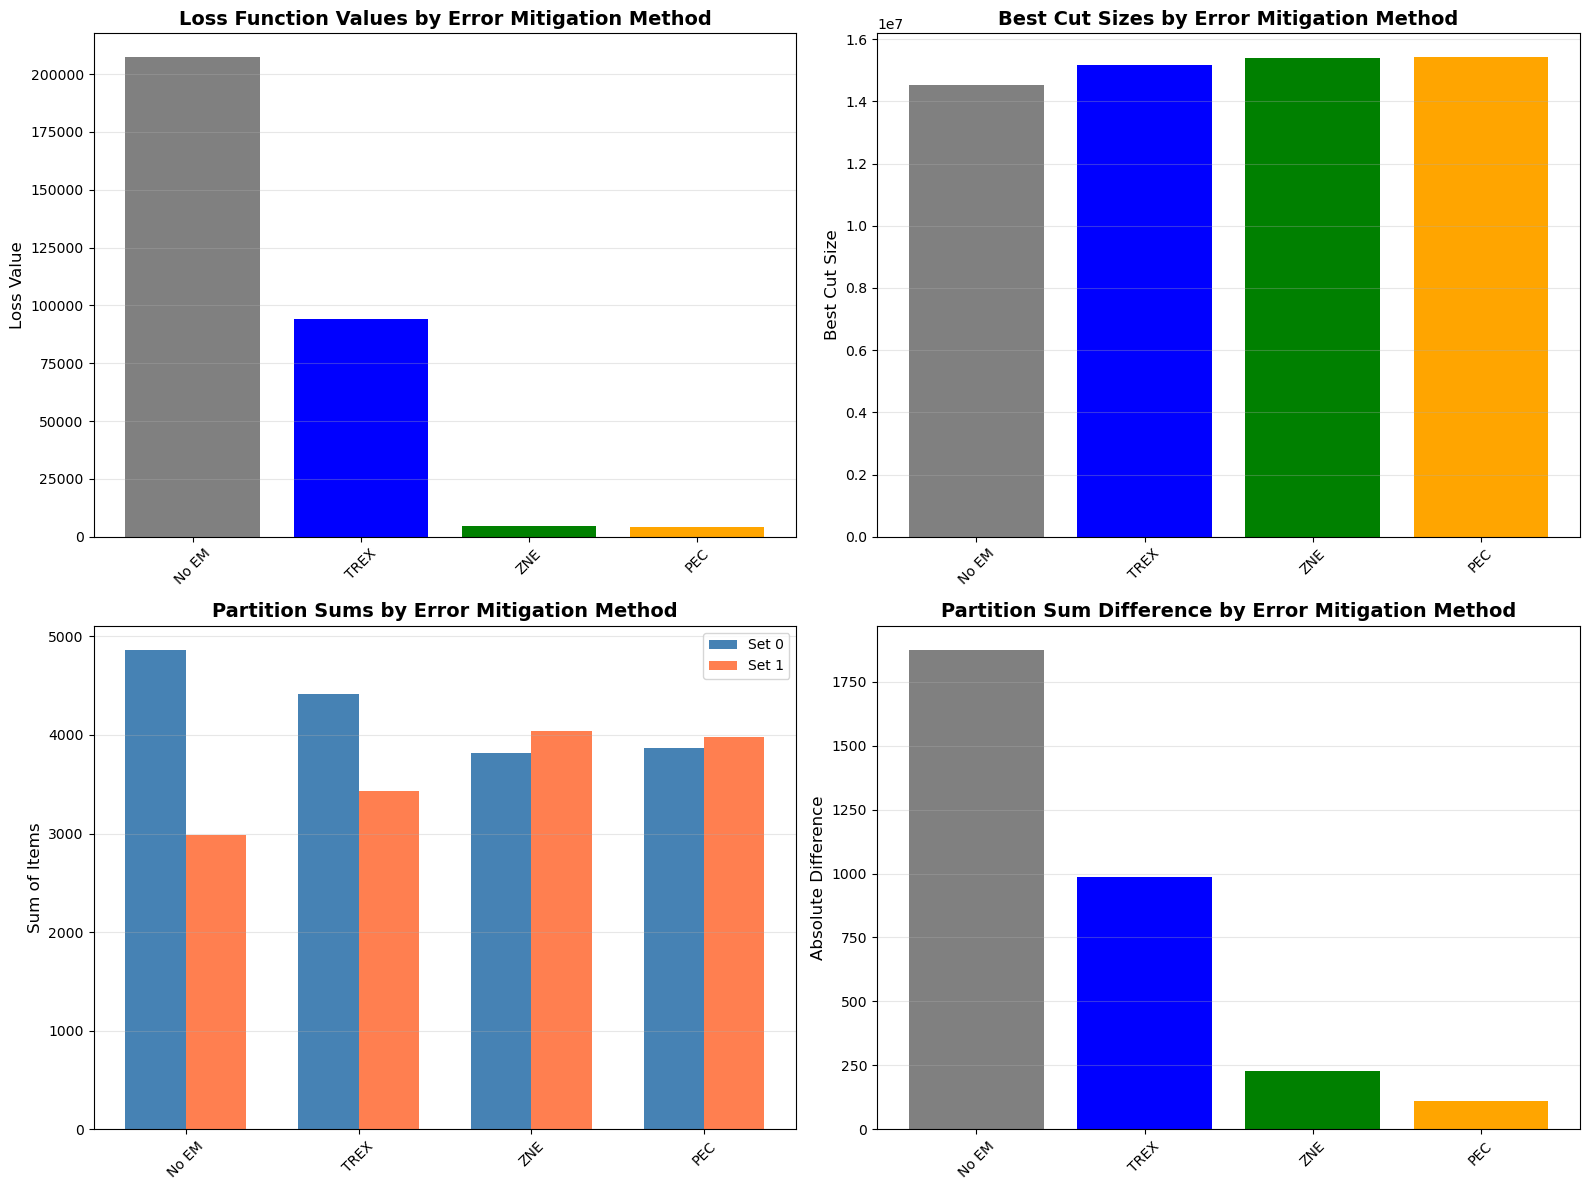
</div>

In [ ]:
estimator_options_list = [
    est_options_no_em,
    est_options_trex,
    est_options_zne,
    est_options_pec,
]
jobs_est_list = [job_no_em, job_trex, job_zne, job_pec]

The grader cell below will verify that your jobs correctly apply the previously defined `EstimatorOptions` and assess the quality of your results to confirm you obtained a valid solution to the partition problem.

In [ ]:
## Verify your answer ##
grade_lab4b_ex4(estimator_options_list, results, jobs_est_list)

## Conclusion

Congratulations on completing Lab 4b! 🎉

In this lab, you explored the partition problem and learned how to formulate it as a QUBO problem suitable for current quantum computers using the QAOA algorithm. You have also experienced how advanced error mitigation and suppression techniques can significantly improve QAOA performance on real quantum hardware. Additionally, you implemented smart encoding strategies that reduce the qubit requirements, enabling you to solve problem instances on current QPUs that would be intractable with naive encoding approaches.

This Lab serves as a demonstration that a combination of the adequate quantum algorithm combined with tailored error-handling strategies and efficient encodings could brings us one step closer to solving real-world problems and demonstrating quantum advantage for classically verifiable problems.

Now, if you enjoyed this problem and are ready to take it to the next level, the bonus section will show you how to tackle a problem 10 times larger: finding the partition of a list containing 1600 numbers!


# Bonus Challenge: Further scaling to a 1600‑node graph

#### Not required for the badge

We now consider a problem with 1600 nodes, which is ten times larger than the example studied previously. Problems of this size start to become significantly more challenging to solve or approximate accurately.

<a id="exercise_bonus"></a>
<div class="alert alert-block alert-success">
    
<b> Bonus exercise: Achieve the best possible result for the partition problem</b>

**Your Goal:** Minimize the difference between the two partition sums as much as possible.

You can do that by following the following techniques:

- **a) Train on hardware** to obtain the optimized parameters for the QAOA circuit.
- **b) Combine multiple error mitigation techniques** to minimize quantum noise effects.
- **c) Implement post-processing refinement** to correct potential bit-flip errors.

For this bonus challenge, scores will range from 0 to 100, where 100 is the best outcome. Your score reflects how well you minimize the difference between the two partitions: the smaller the difference, the better the result. 

*Only results obtained through execution on real hardware will be graded. At least ~ 1 min is needed and ~ 25 min are optional but recommended.*
</div>

In [ ]:
ls

qgss_2026_main/  README.md


#### Solution notes — Bonus: 1600 nodes on 33 qubits

Everything in the bonus section is Section 3 rerun at ten times the size, plus
one genuinely new ingredient.

**The encoding scales well.** `reduce_qubits_with_pce(1600)` gives 33 qubits:
3·33·32/2 = 1584 — which is *less* than 1600, so the ceiling in the formula is
doing real work and the actual value is 33, providing 1584 slots. Ten times the
nodes for three times the qubits is the whole argument for PCE. The graph itself
has 1600·1599/2 ≈ 1.28 million edges, which is why the loss function has to
sample edges rather than sum them all.

**The three parts of the exercise map onto three different kinds of
improvement:**

- **(a) Hardware training** — actually optimise the parameters instead of
  guessing. ~32 s per iteration, 30 iterations, so about 16 minutes of QPU time.
  The `training=False` path with random parameters exists so you can see the
  pipeline work without paying for it, and the gap between the two is the honest
  measure of what the variational loop buys you.
- **(b) Error mitigation** — the configuration from Exercise 4, chosen freely.
  The provided answer takes ZNE (via `resilience_level = 2`) plus measurement
  mitigation and full twirling: PEC's exponential overhead is not affordable on
  a 33-qubit circuit.
- **(c) Classical local search** — `swap_partitions`. This is the part worth
  paying attention to.

**Why the local search matters so much.** The quantum step produces continuous
expectation values, thresholded at zero into bits. Values near zero are
essentially coin flips, and noise will have flipped some of them. Local search
walks the neighbourhood of the quantum answer, flipping single nodes and keeping
improvements. It cannot find a good partition on its own from a random start —
1600 nodes is far too large — but it is very effective at *repairing* an answer
that is already nearly right.

The two optimisations suggested in the markdown are what make it finish in about
a minute: converting to **rustworkx** (Rust-backed graph library) and **sampling
at most 1000 edges** instead of all 1.28 million. The implementation also builds
a weighted adjacency list so a single bit flip can be evaluated in O(degree)
rather than by recomputing the whole cut — the standard trick for local search
on graphs, and the difference between minutes and hours.

This hybrid shape — quantum proposes, classical refines — is the realistic
picture of near-term quantum optimisation, and it is worth being honest that
part (c) is doing a lot of the work here.

In [ ]:
# The whole Section 3 pipeline rerun at 1600 nodes: PCE sizing, three Pauli
# families, combined Hamiltonian, annotated ansatz, transpilation. 1600 nodes
# need only 33 qubits (3*33*32/2 = 1584 correlation slots). The graph has
# ~1.28 million edges, which is why the loss function must sample them.

n_bonus = 1600
# We pre-generated 1600 random integers in [0, 100] using np.random.randint(0, 100, size=n_bonus)
# For reproducibility, we load this pre-generated numbers here
numbers_bonus = np.load("qgss_2026_main/utils/numbers_bonus.npy")

print(f"Numbers to partition: {numbers_bonus}")
print(f"Total sum: {sum(numbers_bonus)}")

partition_graph_bonus = build_partition_graph(numbers_bonus)

print(
    f"\nGraph created with {len(partition_graph_bonus.nodes())} nodes and {len(partition_graph_bonus.edges())} edges"
)

list_size_bonus = n_bonus // 3
node_x_bonus = [i for i in range(list_size_bonus)]
node_y_bonus = [i for i in range(list_size_bonus, 2 * list_size_bonus)]
node_z_bonus = [i for i in range(2 * list_size_bonus, n_bonus)]
num_qubits_bonus = reduce_qubits_with_pce(n_bonus)
print(f"Number of qubits after PCE: {num_qubits_bonus}")
pauli_correlation_encoding_x_bonus = build_pauli_correlation_encoding(
    "X", node_x_bonus, num_qubits_bonus
)
pauli_correlation_encoding_y_bonus = build_pauli_correlation_encoding(
    "Y", node_y_bonus, num_qubits_bonus
)
pauli_correlation_encoding_z_bonus = build_pauli_correlation_encoding(
    "Z", node_z_bonus, num_qubits_bonus
)

layers_bonus = 2
ops_bonus = (
    pauli_correlation_encoding_x_bonus
    + pauli_correlation_encoding_y_bonus
    + pauli_correlation_encoding_z_bonus
)
labels_bonus = []
coeffs_bonus = []
for op in ops_bonus:
    # Each op in your list has exactly one term
    labels_bonus.extend(op.paulis.to_labels())  # returns list of strings
    coeffs_bonus.extend(op.coeffs.tolist())  # numpy -> python floats

hamiltonian_pce_bonus = SparsePauliOp(labels_bonus, coeffs_bonus).simplify()
qc_bonus = annotated_qaoa_ansatz(hamiltonian_pce_bonus, reps=layers_bonus)
edge_coloring = nx.greedy_color(
    nx.line_graph(partition_graph), strategy="saturation_largest_first"
)
edge_coloring.update({(k[1], k[0]): v for k, v in edge_coloring.items()})
num_colors = len(set(edge_coloring.values()))
cmap = CouplingMap(partition_graph.edges())
cmap.make_symmetric()
swap_strategy = SwapStrategy(cmap, ())
staged_pm_bonus = generate_preset_qaoa_pass_manager(
    backend, swap_strategy, initial_layout=None, edge_coloring=edge_coloring
)
pm_bonus = staged_pm_bonus
qc_bonus = pm_bonus.run(UnrollBoxes()(qc_bonus))

pce_bonus = [
    [op.apply_layout(qc_bonus.layout) for op in pauli_correlation_encoding_x_bonus],
    [op.apply_layout(qc_bonus.layout) for op in pauli_correlation_encoding_y_bonus],
    [op.apply_layout(qc_bonus.layout) for op in pauli_correlation_encoding_z_bonus],
]

Numbers to partition: [51 92 14 ... 16 13 30]
Total sum: 78010

Graph created with 1600 nodes and 1279200 edges
Number of qubits after PCE: 34


In [ ]:
backend_bonus = service.least_busy(
    simulator=False, operational=True, min_num_qubits=156
)

qiskit_runtime_service.backends:WARNING:2026-07-31 07:02:48,397: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-07-31 07:02:50,038: Using instance: open-instance, plan: open


<div class="alert alert-block alert-warning">
<b>Warning:</b> Each training iteration takes approximately 32 seconds. 
For 30 iterations, the total estimated QPU runtime is about <b>16 minutes</b>. 
Please plan your execution time accordingly.
</div>


**QPU Time-Saving Option:** If you have limited QPU time, you can skip hardware training by using random parameters with `training=False` and only measure the expectation value on hardware later. Note that skipping training and using random parameters will likely give worse results than optimized parameters. To use this option, uncomment and execute the next cell.


In [ ]:
# The QPU-time-saving path: random parameters, training=False. It exercises the
# full pipeline without the ~16 minutes of hardware training, at the cost of a
# markedly worse partition. The gap between this and the trained run in the next
# cell is the honest measure of what the variational loop is worth.

# Generate random parameters (you can use random values or pi/2 as before)
random_params = np.random.uniform(0, 2*np.pi, qc_bonus.num_parameters)  
np.save('random_params_for_bonus.npy', random_params)
opt_params_bonus, experiment_result_bonus_training = run_pce_optimization(
    qc_bonus,
    backend_bonus,
    pce_bonus,
    partition_graph_bonus,
    loss_func_estimator,
    training=False,
    filename="random_params_for_bonus.npy",
    max_iter=50,
)

If you want to train on hardware instead, execute the next cell.

*Usage estimate: 35 minutes on a Heron r2 processor using Session mode (NOTE: This is an estimate only. Your runtime might vary.)*

*The usage estimate reflects only backend execution. Cell runtime can still take minutes due to queueing, calibration, and session delays. You can check the status of your job in [IBM Quantum Platform](https://quantum.cloud.ibm.com/).*

In [ ]:
opt_params_bonus, experiment_result_bonus_training = run_pce_optimization(
    qc_bonus,
    backend_bonus,
    pce_bonus,
    partition_graph_bonus,
    loss_func_estimator,
    training=True,
    filename="opt_params_bonus_1600_hw.npy",
    max_iter=30,
)

We are using Job mode
Creating new Job: d9m3l5fbupns73e87ed0
Iter 0: 875386.8961858666
Creating new Job: d9m3m57bupns73e87fg0
Iter 1: 459299.7083762102
Creating new Job: d9m3mpfbupns73e87g90
Error: Unable to retrieve results from the job. Please verify that you are passing the correct job variable to the function.
Creating new Job: d9m3o77urbec73e5arbg


: 

: 

### b) Custom Error Mitigation configuration

In this part you are free to explore different error mitigation strategies to try to obtain the best results.

*Usage estimate: 38 seconds on a Heron r2 processor (NOTE: This is an estimate only. Your runtime might vary.)*

*The usage estimate reflects only backend execution. Cell runtime can still take minutes due to queueing, calibration, and session delays. You can check the status of your job in [IBM Quantum Platform](https://quantum.cloud.ibm.com/).*

In [ ]:
# Optimal Error Mitigation Configuration
print("=" * 80)
print("Bonus Scenario: Optimal Error Mitigation Strategy")
print("=" * 80)

# Initialize estimator options
est_options_bonus = EstimatorOptions()

# ---- TODO : Task Bonus ---
# Configure estimator with optimal error mitigation settings

# Set number of measurement shots (higher = better statistics but slower)
est_options_bonus.default_shots = 10000

# Enable resilience level 2 (required for ZNE)
est_options_bonus.resilience_level = 2

# Otherwise Configure Probabilistic Error Cancellation (PEC)
# (Using ZNE via resilience level 2 above; to use PEC instead, set
#  est_options_bonus.resilience.zne_mitigation = False and
#  est_options_bonus.resilience.pec_mitigation = True)

# Enable measurement error mitigation (corrects readout errors)
est_options_bonus.resilience.measure_mitigation = True

# Configure twirling (randomizes coherent errors into stochastic noise)
est_options_bonus.twirling.enable_gates = True
est_options_bonus.twirling.enable_measure = True

# ---- END of TODO : Task Bonus ---

# Create estimator with configured options
estimator_bonus = Estimator(backend_bonus, options=est_options_bonus)
estimator_bonus.options.environment.job_tags = ["qgss26"]
print("\nEstimator Configuration:")
print(f" {est_options_bonus}")

# Evaluate the quantum circuit with error mitigation
experiment_bonus = []
loss_bonus, experiment_bonus, job_bonus = loss_func_estimator(
    opt_params_bonus,
    qc_bonus,
    pce_bonus,
    estimator_bonus,
    partition_graph_bonus,
    experiment_bonus,
)

# Display results
print(f"\nLoss with Advanced Error Mitigation: {loss_bonus:.4f}")

### c) Post-Processing: single-bit flips around the solutions

Even with advanced error mitigation, quantum noise can cause bit-flip errors in the solution. We implement a **local search** strategy to refine the quantum solution:

1. Start with the best solution from the quantum computer
2. Systematically try swapping nodes between partitions
3. Keep swaps that improve the cut size (objective function)
4. This corrects potential errors introduced by quantum noise


In [ ]:
# Threshold the continuous PCE expectation values into bits: >= 0 goes to
# partition 0, < 0 to partition 1. Values close to zero are effectively coin
# flips, and those are exactly the ones noise will have flipped -- which is what
# the local search in the next cells is there to repair.

# Extract the best partition from quantum results

# Get the partitions with highest expectation value
par0, par1, best_index = get_partitions(experiment_bonus)

# Calculate the cut size for this partition
cut_size = calc_cut_size(partition_graph_bonus, par0, par1)

# Convert expectation values to binary representation
# Positive expectation → bit = 1 (partition 0)
# Negative expectation → bit = 0 (partition 1)
cur_bits = []
for i in experiment_bonus[best_index]["exp_map"]:
    if experiment_bonus[best_index]["exp_map"][i] >= 0:
        cur_bits.append(1)
    else:
        cur_bits.append(0)

Let us now implement the `swap_partitions` function.

Since the graph is quite large and contains many edges, you might consider the following strategies to reduce the computational cost of the `swap_partitions` function.

1. Convert the NetworkX graph to a Rustworkx graph, since it is optimized for large graph operations.
2. Use a subset of edges by sampling a portion of the edges, instead of processing the full edge set.

In case you don't have it installed, you can install [Rustworkx](https://www.rustworkx.org/tutorial/introduction.html) by uncommenting the next cell:

In [ ]:
# %pip install rustworkx

In [ ]:
# Local search: flip single nodes, keep improvements. Two optimisations make it
# finish in about a minute on a 1.28-million-edge graph -- conversion to
# rustworkx (Rust-backed), and the weighted adjacency list, which lets a single
# bit flip be scored in O(degree) instead of recomputing the whole cut. The
# max_samples cap bounds how many edges are considered per pass.

def swap_partitions(graph: nx.Graph, cur_bits, max_samples=1000):
    """
    Local search refinement: swap nodes between partitions to improve cut size.

    This function explores the neighborhood of the current solution by trying
    all possible swaps of connected nodes. This helps correct bit-flip errors
    that may have been introduced by quantum noise.

    Parameters
    ----------
    graph : networkx.Graph
        The graph representing the partition problem
    cur_bits : List[int]
        Current partition assignment (1 = partition 0, 0 = partition 1)
    max_samples : int
        Maximum number of edges to sample
    Returns
    -------
    Tuple[float, List[int]]
        best_cut : Best cut size found after exploring swaps
        best_bits : Partition assignment that achieves the best cut
    """

    # ---- TODO : Task Bonus ---
    # --------------------------------------------------
    # 1. Convert NetworkX graph → rustworkx graph
    # --------------------------------------------------
    import rustworkx as rx
    def nx_to_rx(graph_nx):
        rx_graph = rx.PyGraph()

        # Add nodes
        rx_graph.add_nodes_from(list(graph_nx.nodes()))

        # Add edges
        for u, v, w in graph_nx.edges(data="weight"):
            rx_graph.add_edge(u, v, float(w))

        return rx_graph

    graph = nx_to_rx(graph)

    # --------------------------------------------------
    # 2. Fast cut size computation (no sets!)
    # --------------------------------------------------
    n_nodes = graph.num_nodes()
    edge_list = list(graph.weighted_edge_list())  # (u, v, weight)

    # Weighted adjacency for O(degree) delta evaluation on a bit flip
    adjacency = [[] for _ in range(n_nodes)]
    for u, v, w in edge_list:
        adjacency[u].append((v, w))
        adjacency[v].append((u, w))

    def compute_cut(bits):
        return sum(w for u, v, w in edge_list if bits[u] != bits[v])

    best_bits = list(cur_bits)
    best_cut = compute_cut(best_bits)

    # Local search: repeatedly move the single node that most improves the cut
    improved = True
    while improved:
        improved = False
        for i in range(n_nodes):
            bit_i = best_bits[i]
            # delta = (edges that become cut) - (edges that become uncut)
            delta = 0
            for j, w in adjacency[i]:
                if best_bits[j] == bit_i:
                    delta += w   # currently uncut -> becomes cut
                else:
                    delta -= w   # currently cut   -> becomes uncut
            if delta > 0:
                best_bits[i] = 1 - bit_i
                best_cut += delta
                improved = True

    best_cut = int(best_cut)
    # ---- END of TODO : Task Bonus ---
    return best_cut, best_bits

A fast implementation of the `swap_partitions` function using max_samples=1000 should take around 1 minute.

In [ ]:
# Apply local search refinement to quantum solution
best_cut, best_bits = swap_partitions(partition_graph_bonus, cur_bits, max_samples=1000)

# Convert refined bit assignment back to number sets
set0 = [int(numbers_bonus[i]) for i in range(len(numbers_bonus)) if best_bits[i] == 1]
set1 = [int(numbers_bonus[i]) for i in range(len(numbers_bonus)) if best_bits[i] == 0]

# Compile final results
result_bonus = {
    "loss": loss_bonus,  # Quantum loss function value
    "par0": list(par0),  # Original partition 0 from quantum
    "par1": list(par1),  # Original partition 1 from quantum
    "par0_size": len(par0),  # Size of partition 0
    "par1_size": len(par1),  # Size of partition 1
    "best_cut": np.float64(best_cut),  # Best cut after refinement
    "best_index": best_index,  # Index of best quantum result
    "set0": set0,  # Refined set 0 (actual numbers)
    "set1": set1,  # Refined set 1 (actual numbers)
    "difference": abs(int(sum(set0) - sum(set1))),  # Final partition difference
    "exp_map": experiment_bonus[best_index]["exp_map"],
}

# Display the final partition difference (goal: minimize to 0 or 1)
print(f"Final partition difference after refinement: {result_bonus['difference']}")
print(f"Sum of set 0: {sum(set0)}")
print(f"Sum of set 1: {sum(set1)}")

In [ ]:
## Verify your answer ##
grade_lab4b_exbonus(result_bonus, best_bits, numbers_bonus, job_bonus)

Well done! You have completed the Bonus challenge! 

# Additional information

**Created by:** Jorge Martínez de Lejarza

**Version:** 1.0.0